# Financial Market Clustering Pipeline
**Purpose**: Preprocess stock features, apply dimensionality reduction, and train clustering models for Streamlit visualization.

**Structure**: Matches R paper `ComparativeAnalysis.Rmd` methodology.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn_extra.cluster import KMedoids
from scipy.cluster.hierarchy import linkage, fcluster, cophenet
from scipy.spatial.distance import pdist, squareform

# Metrics
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, silhouette_samples
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration
RANDOM_STATE = 42
DATA_PATH = 'paper1_clustering/data/raw/ds1_global_data.parquet'
OUTPUT_DIR = Path('paper1_clustering/results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set display options
pd.options.display.float_format = '{:.4f}'.format
plt.style.use('seaborn-v0_8')

## 1. Data Loading & Preprocessing
**Purpose**: Load raw data and prepare features for clustering analysis.

### 1.1 Load Data

In [2]:
# Load data
global_data = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(global_data)} stocks with {global_data.shape[1]-1} features")

# Separate tickers and features
tickers = global_data['ticker'].values
features = global_data.drop(columns=['ticker'])

# Remove zero variance features (if any)
variances = features.var()
zero_var_features = variances[variances == 0].index.tolist()
if zero_var_features:
    features = features.drop(columns=zero_var_features)
    print(f"Removed {len(zero_var_features)} zero variance features")

print(f"Final feature count: {features.shape[1]}")
features.head()

Loaded 48 stocks with 20 features
Final feature count: 20


,mean_daily_return,mean_momentum_20d,mean_close_vs_sma200,mean_stock_vs_market,beta_global,mean_volatility_20d,mean_sharpe_20d,worst_drawdown,mean_atr_14,mean_volatility_ratio,mean_rsi_14,mean_adx_14,mean_macd_hist,mean_stoch_k,mean_bb_width,mean_liquidity_20d,mean_volume_ratio,mean_price_pos_20d,return_skewness,return_kurtosis
0,0.0007,0.0153,0.0537,0.0001,1.2106,0.0171,1.3189,-0.3343,5.2651,0.9060,54.2548,22.5954,0.0444,59.1044,0.1185,12024456575.2846,1.0116,0.6071,1.0468,14.2810
1,0.0007,0.0131,0.0616,0.0001,0.3785,0.0158,1.2775,-0.2146,4.3975,0.9409,54.0229,27.7884,-0.0644,55.4352,0.1161,1195324899.3901,1.0160,0.5578,-1.3934,10.4699
2,0.0010,0.0232,0.0693,0.0004,1.3583,0.0200,1.0745,-0.3088,5.5864,0.9396,53.4888,21.5816,0.0939,57.6415,0.1276,8885106527.7359,1.0185,0.5992,0.4448,5.3031
3,0.0011,0.0283,0.1108,0.0005,1.3188,0.0179,1.4466,-0.2899,6.9685,0.9173,55.4848,20.8174,0.0580,62.0397,0.1212,809776313.2010,1.0100,0.6426,0.6255,9.5002
4,0.0005,0.0150,0.0479,-0.0000,1.1278,0.0212,0.8436,-0.4831,5.5515,0.9211,52.0128,25.6381,-0.0483,50.6150,0.1533,1670663097.7731,1.0249,0.5046,0.3345,8.4168


In [3]:
### 1.2 Feature Transformation (Yeo-Johnson + Standardization)
**Purpose**: Normalize skewed features and standardize for distance-based clustering.

SyntaxError: invalid syntax (515332674.py, line 2)

Features with |skewness| > 2.0: 6
['return_kurtosis', 'mean_liquidity_20d', 'mean_volume_ratio', 'worst_drawdown', 'return_skewness'] ...


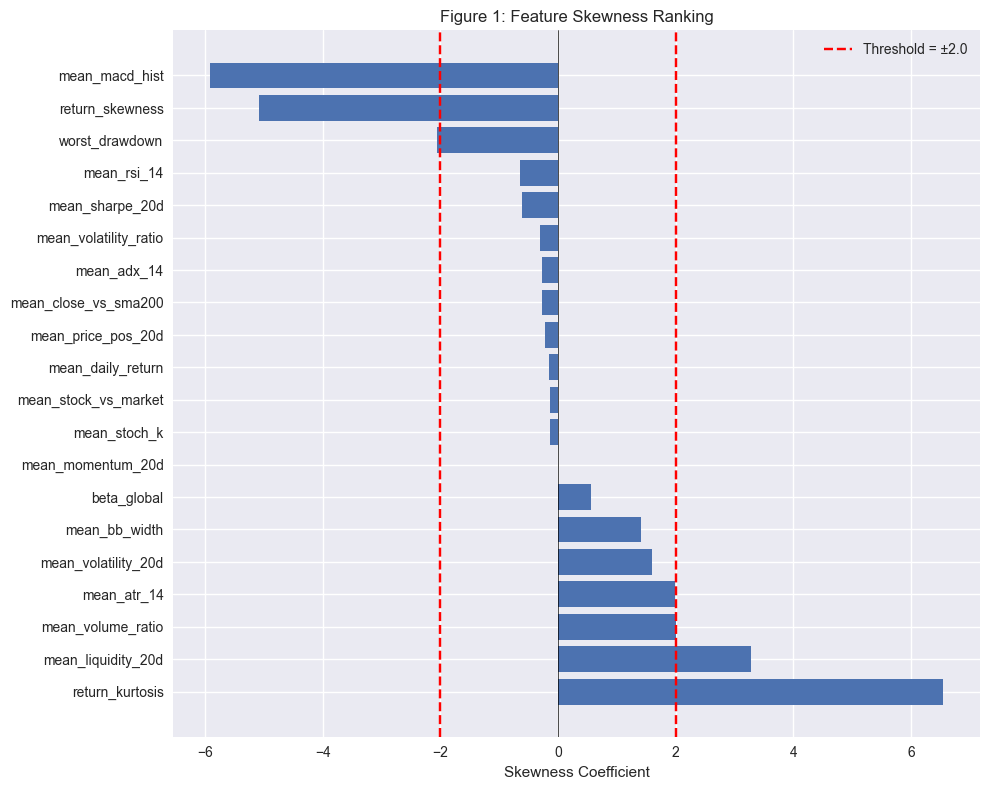


✓ Applied Yeo-Johnson to 6 features
✓ Standardized all 20 features


In [4]:
# Identify skewed features (threshold = 2.0, matching R paper)
SKEW_THRESHOLD = 2.0
skewness_vals = features.skew().sort_values(ascending=False)
skewed_features = skewness_vals[abs(skewness_vals) > SKEW_THRESHOLD].index.tolist()

print(f"Features with |skewness| > {SKEW_THRESHOLD}: {len(skewed_features)}")
if len(skewed_features) > 0:
    print(skewed_features[:5], "..." if len(skewed_features) > 5 else "")

# Visualize skewness
plt.figure(figsize=(10, 8))
skew_df = pd.DataFrame({'feature': skewness_vals.index, 'skewness': skewness_vals.values})
skew_df = skew_df.sort_values('skewness', ascending=False)
plt.barh(range(len(skew_df)), skew_df['skewness'])
plt.yticks(range(len(skew_df)), skew_df['feature'])
plt.axvline(x=SKEW_THRESHOLD, color='r', linestyle='--', label=f'Threshold = ±{SKEW_THRESHOLD}')
plt.axvline(x=-SKEW_THRESHOLD, color='r', linestyle='--')
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.xlabel('Skewness Coefficient')
plt.title('Figure 1: Feature Skewness Ranking')
plt.legend()
plt.tight_layout()
plt.show()

# Apply Yeo-Johnson transformation
features_transformed = features.copy()
transformers = {}
for feat in skewed_features:
    pt = PowerTransformer(method='yeo-johnson', standardize=False)
    features_transformed[feat] = pt.fit_transform(features[[feat]]).flatten()
    transformers[feat] = pt

# Standardize all features
scaler = StandardScaler()
features_scaled = pd.DataFrame(
    scaler.fit_transform(features_transformed),
    columns=features_transformed.columns,
    index=features_transformed.index
)

print(f"\n✓ Applied Yeo-Johnson to {len(skewed_features)} features")
print(f"✓ Standardized all {features_scaled.shape[1]} features")

In [ ]:
## 2. Dimensionality Reduction (PCA)
**Purpose**: Reduce multicollinearity and noise, retain 3 components (67.4% variance) as per R paper.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticker                 48 non-null     object 
 1   mean_daily_return      48 non-null     float64
 2   mean_momentum_20d      48 non-null     float64
 3   mean_close_vs_sma200   48 non-null     float64
 4   mean_stock_vs_market   48 non-null     float64
 5   beta_global            48 non-null     float64
 6   mean_volatility_20d    48 non-null     float64
 7   mean_sharpe_20d        48 non-null     float64
 8   worst_drawdown         48 non-null     float64
 9   mean_atr_14            48 non-null     float64
 10  mean_volatility_ratio  48 non-null     float64
 11  mean_rsi_14            48 non-null     float64
 12  mean_adx_14            48 non-null     float64
 13  mean_macd_hist         48 non-null     float64
 14  mean_stoch_k           48 non-null     float64
 15  mean_bb_

PCA Results (n_components=3):
  Individual variance: [0.41754383 0.17622214 0.10936298]
  Cumulative variance: 70.3%


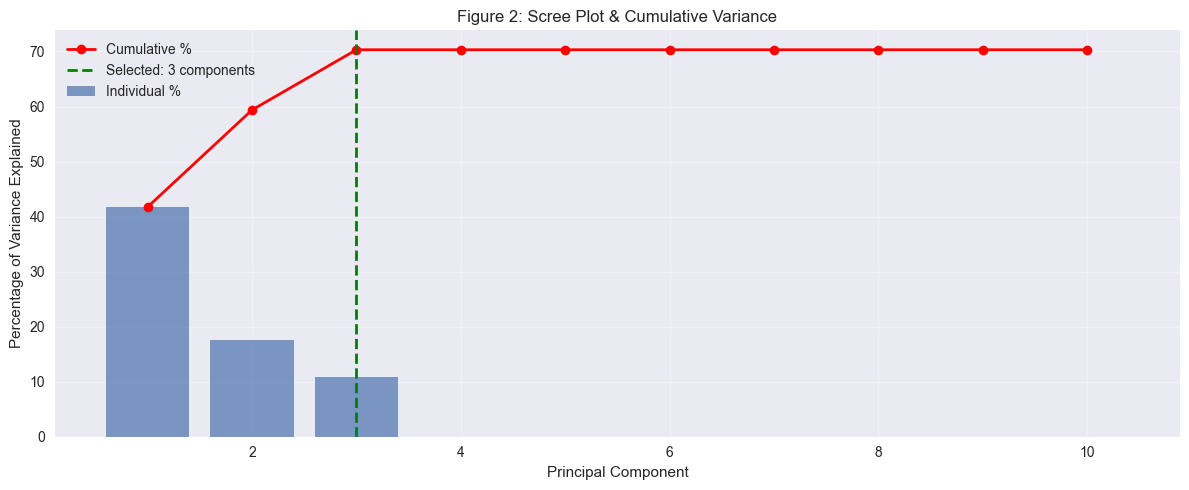


✓ Reduced 20 features to 3 principal components


In [5]:
# Apply PCA with 3 components (matching R paper)
N_COMPONENTS = 3
pca = PCA(n_components=N_COMPONENTS)
features_pca = pca.fit_transform(features_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print(f"PCA Results (n_components={N_COMPONENTS}):")
print(f"  Individual variance: {explained_var}")
print(f"  Cumulative variance: {cumulative_var[-1]:.1%}")

# Visualize explained variance
eig_val = pd.DataFrame({
    'PC': range(1, 11),
    'variance_percent': [pca.explained_variance_ratio_[i] * 100 if i < len(pca.explained_variance_ratio_) else 0 
                         for i in range(10)],
    'cumulative_percent': [(pca.explained_variance_ratio_[:min(i+1, len(pca.explained_variance_ratio_))].sum() * 100)
                          for i in range(10)]
})

plt.figure(figsize=(12, 5))
plt.bar(eig_val['PC'][:10], eig_val['variance_percent'][:10], alpha=0.7, label='Individual %')
plt.plot(eig_val['PC'][:10], eig_val['cumulative_percent'][:10], 'ro-', linewidth=2, label='Cumulative %')
plt.axvline(x=N_COMPONENTS, color='g', linestyle='--', linewidth=2, label=f'Selected: {N_COMPONENTS} components')
plt.xlabel('Principal Component')
plt.ylabel('Percentage of Variance Explained')
plt.title('Figure 2: Scree Plot & Cumulative Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

features_pca = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(N_COMPONENTS)])
print(f"\n✓ Reduced {features_scaled.shape[1]} features to {N_COMPONENTS} principal components")


## 3. Optimal Number of Clusters
**Purpose**: Determine optimal k using multiple validation metrics (matching R paper approach).


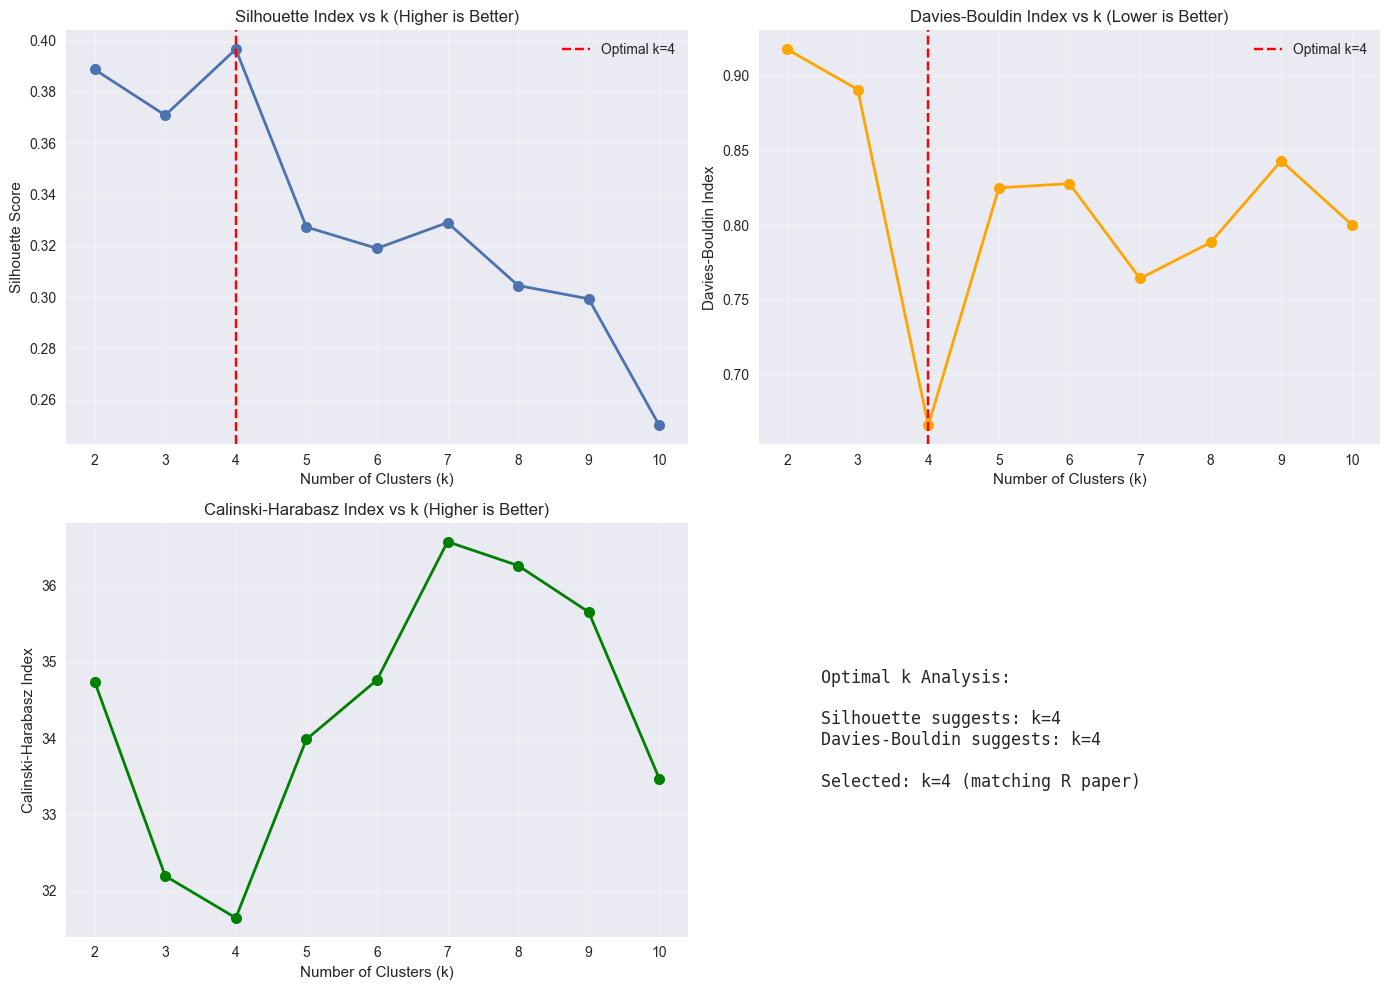


✓ Selected optimal k = 4 (matching R paper)


In [6]:
# Find optimal k (matching R paper methodology)
k_range = range(2, 11)
optimal_k_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(features_pca)
    
    sil = silhouette_score(features_pca, labels)
    db = davies_bouldin_score(features_pca, labels)
    ch = calinski_harabasz_score(features_pca, labels)
    
    optimal_k_results.append({'k': k, 'silhouette': sil, 'davies_bouldin': db, 'calinski_harabasz': ch})

optimal_k_df = pd.DataFrame(optimal_k_results)

# Visualize metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Silhouette (higher is better)
axes[0, 0].plot(optimal_k_df['k'], optimal_k_df['silhouette'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Silhouette Index vs k (Higher is Better)')
axes[0, 0].grid(True, alpha=0.3)
optimal_k_sil = optimal_k_df.loc[optimal_k_df['silhouette'].idxmax(), 'k']
axes[0, 0].axvline(x=optimal_k_sil, color='r', linestyle='--', label=f'Optimal k={optimal_k_sil}')
axes[0, 0].legend()

# Davies-Bouldin (lower is better)
axes[0, 1].plot(optimal_k_df['k'], optimal_k_df['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='orange')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Davies-Bouldin Index')
axes[0, 1].set_title('Davies-Bouldin Index vs k (Lower is Better)')
axes[0, 1].grid(True, alpha=0.3)
optimal_k_db = optimal_k_df.loc[optimal_k_df['davies_bouldin'].idxmin(), 'k']
axes[0, 1].axvline(x=optimal_k_db, color='r', linestyle='--', label=f'Optimal k={optimal_k_db}')
axes[0, 1].legend()

# Calinski-Harabasz (higher is better)
axes[1, 0].plot(optimal_k_df['k'], optimal_k_df['calinski_harabasz'], 'o-', linewidth=2, markersize=8, color='green')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Calinski-Harabasz Index')
axes[1, 0].set_title('Calinski-Harabasz Index vs k (Higher is Better)')
axes[1, 0].grid(True, alpha=0.3)

# Summary table
axes[1, 1].axis('off')
summary_text = f"Optimal k Analysis:\n\n"
summary_text += f"Silhouette suggests: k={optimal_k_sil}\n"
summary_text += f"Davies-Bouldin suggests: k={optimal_k_db}\n"
summary_text += f"\nSelected: k=4 (matching R paper)"
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center', family='monospace')

plt.tight_layout()
plt.show()

# Set optimal k = 4 (matching R paper)
OPTIMAL_K = 4
print(f"\n✓ Selected optimal k = {OPTIMAL_K} (matching R paper)")


## 4. Clustering Models
**Purpose**: Train multiple clustering algorithms matching R paper methodology.


In [7]:
# Import the pipeline functions (or define them here)
# For now, we'll define key functions inline

def compute_metrics(data, labels):
    """Compute validation metrics."""
    return {
        'silhouette': silhouette_score(data, labels),
        'davies_bouldin': davies_bouldin_score(data, labels),
        'calinski_harabasz': calinski_harabasz_score(data, labels)
    }

all_clusterings = {}

# K-Means
print("Training K-Means...")
km = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10, max_iter=300)
km_labels = km.fit_predict(features_pca)
all_clusterings['K-Means'] = {
    'model': km,
    'labels': km_labels,
    'metrics': compute_metrics(features_pca, km_labels)
}

# PAM (Euclidean, Manhattan, Cosine)
print("Training PAM (Euclidean, Manhattan, Cosine)...")
for metric in ['euclidean', 'manhattan', 'cosine']:
    pam = KMedoids(n_clusters=OPTIMAL_K, metric=metric, random_state=RANDOM_STATE)
    pam_labels = pam.fit_predict(features_pca)
    all_clusterings[f'PAM_{metric.capitalize()}'] = {
        'model': pam,
        'labels': pam_labels,
        'metrics': compute_metrics(features_pca, pam_labels),
        'medoids': tickers[pam.medoid_indices_]
    }

# Hierarchical Clustering
print("Training Hierarchical Clustering...")
for dist_metric, linkage_method in [('euclidean', 'ward'), ('euclidean', 'average'), ('cosine', 'average')]:
    if linkage_method == 'ward':
        # Ward requires Euclidean distance and raw data (not distance matrix)
        Z = linkage(features_pca, method='ward')
        dist_matrix = pdist(features_pca, metric='euclidean')
    else:
        # For other methods, compute distance matrix first
        if dist_metric == 'cosine':
            dist_matrix = pdist(features_pca, metric='cosine')
        elif dist_metric == 'euclidean':
            dist_matrix = pdist(features_pca, metric='euclidean')
        Z = linkage(dist_matrix, method=linkage_method)
    
    hc_labels = fcluster(Z, OPTIMAL_K, criterion='maxclust')
    cophenetic_corr = cophenet(Z, dist_matrix)[0] if linkage_method != 'ward' else None
    
    metrics = compute_metrics(features_pca, hc_labels)
    if cophenetic_corr is not None:
        metrics['cophenetic_corr'] = cophenetic_corr
    
    method_name = f'HC_{dist_metric.capitalize()}_{linkage_method.capitalize()}'
    all_clusterings[method_name] = {
        'linkage_matrix': Z,
        'labels': hc_labels,
        'metrics': metrics
    }

# DBSCAN (for outlier detection)
print("Training DBSCAN...")
dbscan = DBSCAN(eps=1.9, min_samples=4)
dbscan_labels = dbscan.fit_predict(features_pca)
all_clusterings['DBSCAN'] = {
    'model': dbscan,
    'labels': dbscan_labels,
    'n_clusters': len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0),
    'n_noise': list(dbscan_labels).count(-1)
}

print(f"\n✓ Trained {len(all_clusterings)} clustering models")


Training K-Means...
Training PAM (Euclidean, Manhattan, Cosine)...
Training Hierarchical Clustering...
Training DBSCAN...

✓ Trained 8 clustering models


## 5. Metrics Comparison & ARI Matrix
**Purpose**: Compare methods and compute pairwise agreement (matching R paper Figure 9).


Metrics Summary (sorted by Silhouette Score):
                 method  silhouette  davies_bouldin  calinski_harabasz  \
0               K-Means      0.3966          0.6661            31.6448   
5  HC_Euclidean_Average      0.3563          0.5819            17.9882   
4     HC_Euclidean_Ward      0.2717          0.9613            26.6450   
3            PAM_Cosine      0.2625          1.1419            23.5872   
1         PAM_Euclidean      0.2420          1.0591            25.3490   
6     HC_Cosine_Average      0.2387          0.9080            22.3719   
2         PAM_Manhattan      0.2362          1.4556            20.4026   
7                DBSCAN         NaN             NaN                NaN   

   cophenetic_corr  
0              NaN  
5           0.7899  
4              NaN  
3              NaN  
1              NaN  
6           0.8228  
2              NaN  
7              NaN  


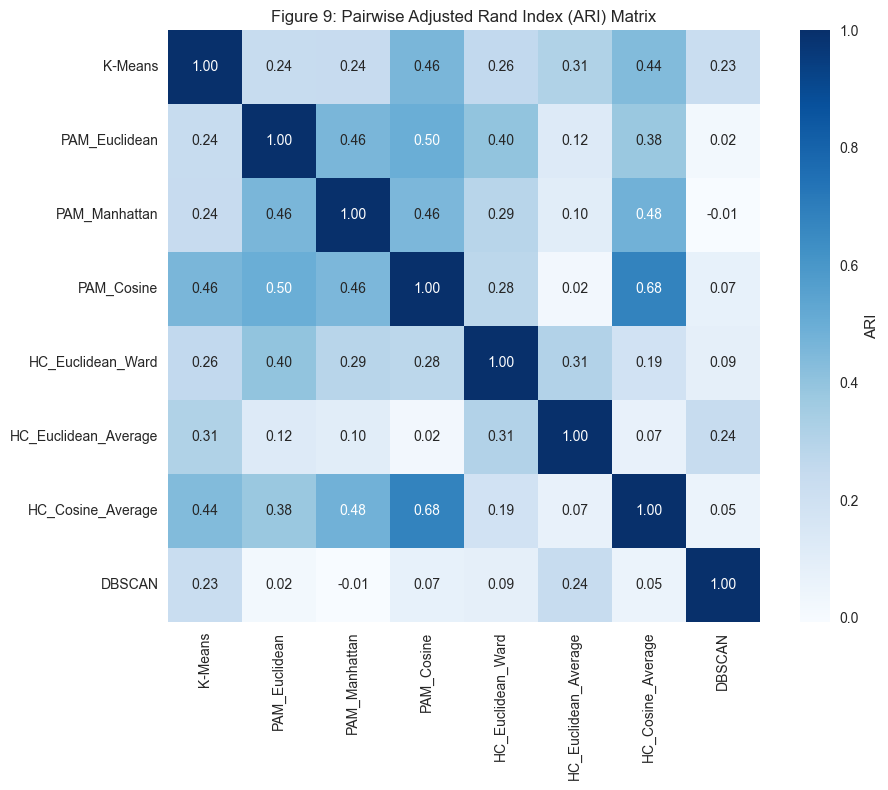


✓ Computed ARI matrix for 8 methods


In [8]:
# Create metrics summary table
metrics_summary = []
for name, result in all_clusterings.items():
    row = {'method': name}
    if 'metrics' in result:
        row.update(result['metrics'])
    metrics_summary.append(row)

metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df.sort_values('silhouette', ascending=False)
print("Metrics Summary (sorted by Silhouette Score):")
print(metrics_df.round(4))

# Compute ARI matrix
method_names = list(all_clusterings.keys())
n_methods = len(method_names)
ari_matrix = np.zeros((n_methods, n_methods))

for i, name1 in enumerate(method_names):
    for j, name2 in enumerate(method_names):
        if i == j:
            ari_matrix[i, j] = 1.0
        else:
            labels1 = all_clusterings[name1]['labels']
            labels2 = all_clusterings[name2]['labels']
            ari_matrix[i, j] = adjusted_rand_score(labels1, labels2)

ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)

# Visualize ARI matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ari_df, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': 'ARI'}, square=True)
plt.title('Figure 9: Pairwise Adjusted Rand Index (ARI) Matrix')
plt.tight_layout()
plt.show()

print(f"\n✓ Computed ARI matrix for {n_methods} methods")


## 6. Save Results for Streamlit
**Purpose**: Export all models, results, and data for Streamlit visualization.


In [ ]:
# Save preprocessed data
preprocessed_data = {
    'tickers': tickers,
    'features_scaled': features_scaled,
    'features_pca': features_pca,
    'scaler': scaler,
    'transformers': transformers,
    'pca_model': pca
}

with open(OUTPUT_DIR / 'preprocessed_data.pkl', 'wb') as f:
    pickle.dump(preprocessed_data, f)

# Save clustering results (excluding models, save separately)
clustering_results = {}
for name, result in all_clusterings.items():
    clustering_results[name] = {
        'labels': result['labels'],
        'metrics': result.get('metrics', {}),
        'medoids': result.get('medoids', None)
    }
    # Save models separately
    if 'model' in result:
        with open(OUTPUT_DIR / f'model_{name.replace(" ", "_")}.pkl', 'wb') as f:
            pickle.dump(result['model'], f)
    if 'linkage_matrix' in result:
        clustering_results[name]['linkage_matrix'] = result['linkage_matrix']

with open(OUTPUT_DIR / 'clustering_results.pkl', 'wb') as f:
    pickle.dump(clustering_results, f)

# Save metrics and ARI matrix
metrics_df.to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
metrics_df.to_json(OUTPUT_DIR / 'metrics_summary.json', indent=2, orient='records')
ari_df.to_csv(OUTPUT_DIR / 'ari_matrix.csv')
ari_df.to_json(OUTPUT_DIR / 'ari_matrix.json', indent=2)

# Save optimal k results
optimal_k_df.to_csv(OUTPUT_DIR / 'optimal_k_analysis.csv', index=False)

# Save cluster assignments for Streamlit
results_df = pd.DataFrame({
    'ticker': tickers,
    **{name: result['labels'] for name, result in all_clusterings.items()}
})
results_df.to_csv(OUTPUT_DIR / 'cluster_assignments.csv', index=False)
results_df.to_parquet(OUTPUT_DIR / 'cluster_assignments.parquet')

print(f"\n✓ Saved all results to {OUTPUT_DIR}")
print(f"  - Preprocessed data: preprocessed_data.pkl")
print(f"  - Clustering results: clustering_results.pkl")
print(f"  - Metrics summary: metrics_summary.csv/json")
print(f"  - ARI matrix: ari_matrix.csv/json")
print(f"  - Cluster assignments: cluster_assignments.csv/parquet")
print(f"  - Individual models: model_*.pkl")


In [265]:
numeric_cols = global_data.select_dtypes(include=[np.number]).columns.tolist()

# Separate features and labels
tickers = global_data['ticker']
features = global_data.drop(columns=['ticker'])

In [320]:
SYMBOL_TO_RISK_CATEGORY = {
    # --- TIER 1: CONSERVATIVE (Low Volatility / Safe Haven) ---
    # Characteristics: Low Beta (<0.8), High Dividend, Capital Preservation.
    # Even if they are "Tech" (like CSCO), they trade like bonds now.
    "KO": "Conservative",   # Consumer Staples
    "PEP": "Conservative",  # Consumer Staples
    "PG": "Conservative",   # Consumer Staples
    "WMT": "Conservative",  # Retail Defensive
    "COST": "Conservative", # Quality Defensive
    "TGT": "Conservative",  # Retail Defensive (shifted from Core due to lower beta recently)
    
    "JNJ": "Conservative",  # Pharma
    "MRK": "Conservative",  # Pharma
    "PFE": "Conservative",  # Pharma
    "ABBV": "Conservative", # Pharma
    
    "T": "Conservative",    # Telecom (Yield proxy)
    "CMCSA": "Conservative",# Media/Utility-like
    "NEE": "Conservative",  # Utility
    
    # --- TIER 2: CORE (Market Correlation / Quality Cyclical) ---
    # Characteristics: Beta ~1.0, Economic backbone, Strong Cash Flow.
    # These move with the S&P 500 (SPY).
    "SPY": "Core",          # The Benchmark itself
    
    # Financials
    "JPM": "Core", "BAC": "Core", "WFC": "Core", 
    "GS": "Core", "MS": "Core", "AXP": "Core", "HSBC": "Core",
    "V": "Core", "MA": "Core", # Payments are economic proxies
    
    # Old Tech / Enterprise (Stable)
    "MSFT": "Core",         # Traded as a Safety/Quality hybrid
    "AAPL": "Core",         # Massive liquidity makes it a market proxy
    "GOOGL": "Core",        # Advertising proxy
    "CSCO": "Core",         # Old Tech / Dividend
    "IBM": "Core",          # Old Tech / Dividend
    "ORCL": "Core",         # Enterprise Stability
    
    # Industrial / Energy / Cyclical
    "CAT": "Core",          # Industrial Bellwether
    "HD": "Core",           # Housing/Consumer
    "DIS": "Core",          # Media
    "TM": "Core",           # Toyota (Stable Auto)
    "XOM": "Core", "CVX": "Core", "COP": "Core", # Energy Giants
    
    # --- TIER 3: AGGRESSIVE (High Volatility / Momentum / Distressed) ---
    # Characteristics: Beta > 1.5, or Idiosyncratic "Event" Risk.
    # These detach from the market (either rocket up or crash down).
    
    # The AI / Momentum Rockets
    "NVDA": "Aggressive",
    "META": "Aggressive",   # High volatility recovery
    "AMZN": "Aggressive",   # Higher beta than AAPL/MSFT
    "NFLX": "Aggressive",
    "TSM": "Aggressive",    # Semi volatility
    "LLY": "Aggressive",    # Pharma, but trades like Tech (GLP-1 hype)
    
    # The "High Volatility" / Distressed
    "TSLA": "Aggressive",   # Extreme swings
    "BA": "Aggressive",     # Boeing Crisis
    "INTC": "Aggressive",   # Turnaround risk
    "BABA": "Aggressive",   # China Risk
    
    # Cyclical High Beta
    "F": "Aggressive",      # Ford (EV transition risk)
    "GM": "Aggressive",     # GM (EV transition risk)
}

## 2.2 Exploratory Data Analysis ("Data Health Check")
Goal: Understand the raw data's shape and quality before touching it

### 2.2.1 Zero variance handling
Why should we do it?
<br>&rarr; If a column is all zeros, plotting it or checking skewness is a waste of time. We should remove it before doing anything deep analysis

In [266]:
def remove_zero_variance(data):
    variances = data.var()
    zero_var_features = variances[variances == 0].index.tolist()
    
    numeric_cols = []
    if zero_var_features:
        print(f"Found {len(zero_var_features)} features with zero variance")
        numeric_cols = [col for col in data.columns if col not in zero_var_features]
        print(f"Remaining features: {len(numeric_cols)}")
    else:
        print("No zero variance features found")
    
    return numeric_cols

In [267]:
column_to_remove = remove_zero_variance(features)

No zero variance features found


### 2.2.2 Outlier Detection

In [268]:
def IQR(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    upper = df[variable].quantile(0.75) + (IQR * 1.5)
    lower = df[variable].quantile(0.25) - (IQR * 1.5)
    return upper, lower

def outliers_detection(data):
    outlier = []
    for var in data.columns:
        upper, lower = IQR(data, var)
        if data[var].max() > (upper + (upper - lower) * 1.5):
            outlier.append(var)
            print(f"{var} has outliers > 1.5IQR {data[var].max():.2f}")
        elif data[var].min() < (lower - (upper - lower) * 1.5):
            outlier.append(var)
            print(f"{var} has outliers < 1.5IQR {data[var].min():.2f}")
            
    return outlier

In [269]:
outliers_list = outliers_detection(features)

mean_macd_hist has outliers < 1.5IQR -2.39
mean_liquidity_20d has outliers > 1.5IQR 38372281288.31
return_skewness has outliers < 1.5IQR -13.91
return_kurtosis has outliers > 1.5IQR 224.00


### 2.2.3 Multicollinearity Check
Identify which features are duplicates so we know what PCA needs to fix later

In [270]:
def correlation_analysis(data, corr_threshold):
    corr_matrix = data.corr()

    plt.figure(figsize=(20, 16))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()
    
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > corr_threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_val
                ))
    
    return high_corr_pairs

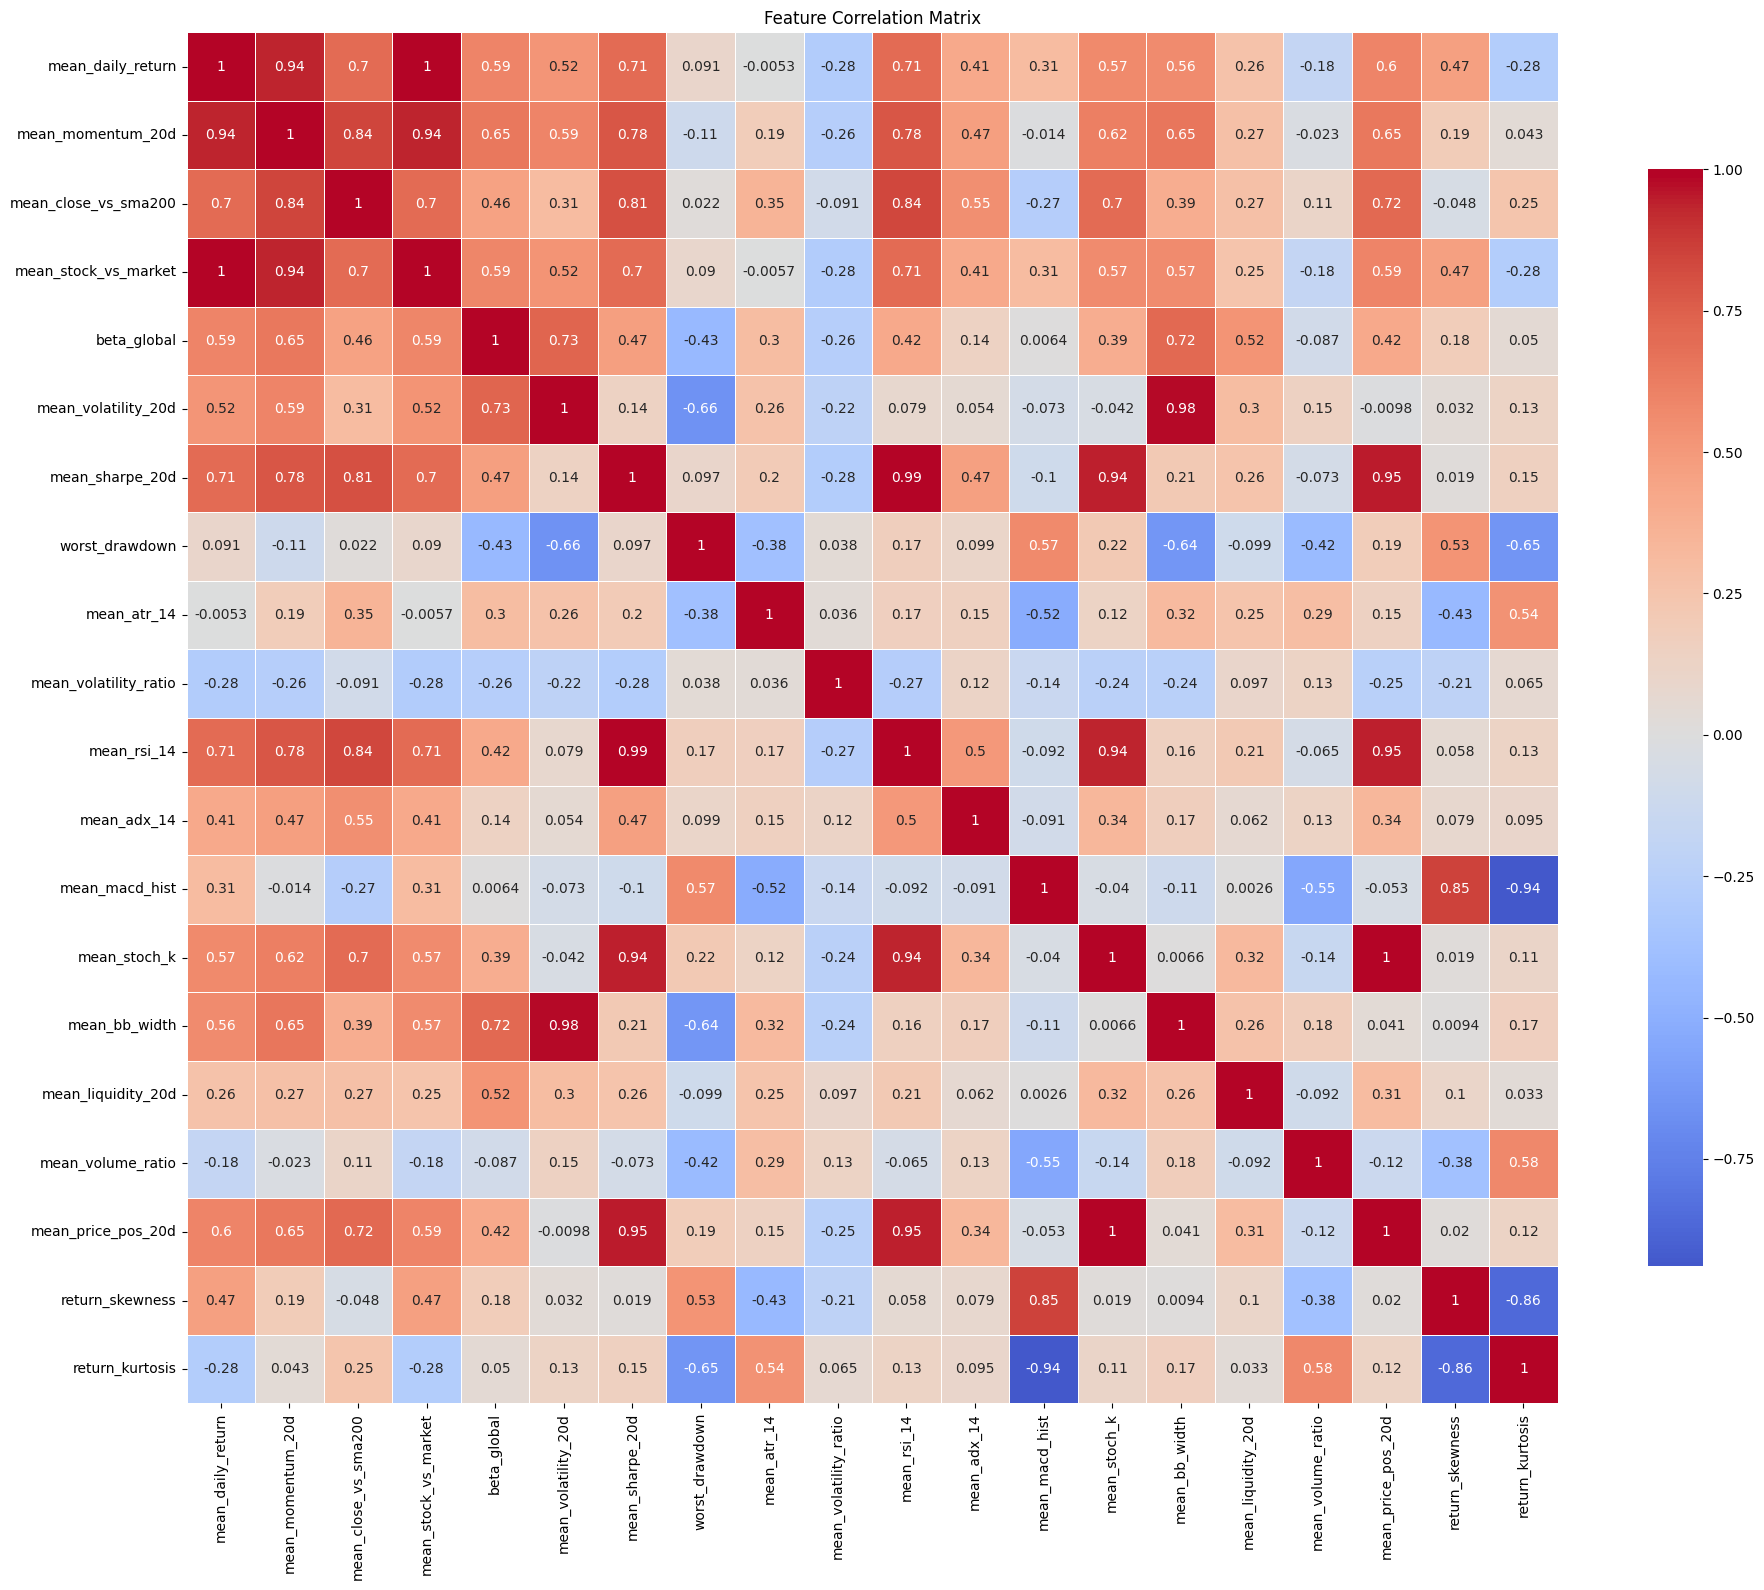

In [271]:
high_corr_pairs = correlation_analysis(features, 0.8)

Need some comments here, will comeback later

## 2.3 Feature Preprocessing ("Data Cleanup")

### 2.3.1 Skewness correction

In [277]:
def skewness_analysis(data, skew_threshold):
        
    skewness = data.skew().sort_values(ascending=False)
    skew_data = []
    normal_data = []

    for feat, skew_val in skewness.items():
        if skew_val > skew_threshold or skew_val < - skew_threshold:
            skew_data.append(feat)
        else:
            normal_data.append(feat)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=skewness.values, y=skewness.index)
    plt.axvline(x=skew_threshold, color='r', linestyle='--', linewidth=1, label=f'High Positive Skew (+{skew_threshold})')
    plt.axvline(x=-skew_threshold, color='r', linestyle='--', linewidth=1, label=f'High Negative Skew (-{skew_threshold})')
    plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    plt.title('Feature Skewness Ranking', fontsize=15)
    plt.xlabel('Skewness Coefficient')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return skew_data, normal_data

def skew_transformation(data, skew_list):
    """
    Apply transformation for highly skewed data
    """
    data_transformed = data.copy()

    for feat in skew_list:
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        data_transformed[feat] = pt.fit_transform(data[[feat]]).flatten()
    
    print(f"Applied Yeo-Johnson transformation for {len(skew_list)} values")

    return data_transformed

In [278]:
skew_threshold = 1

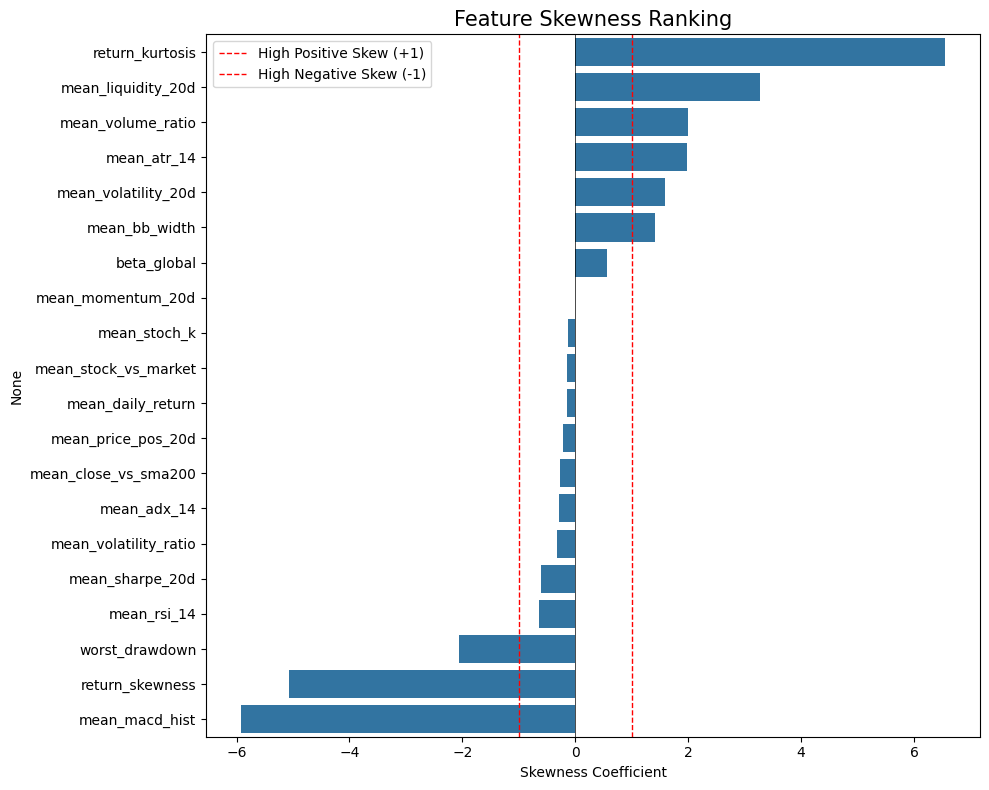

In [279]:
skew_data, normal_data = skewness_analysis(features, skew_threshold)

Applied Yeo-Johnson transformation for 9 values


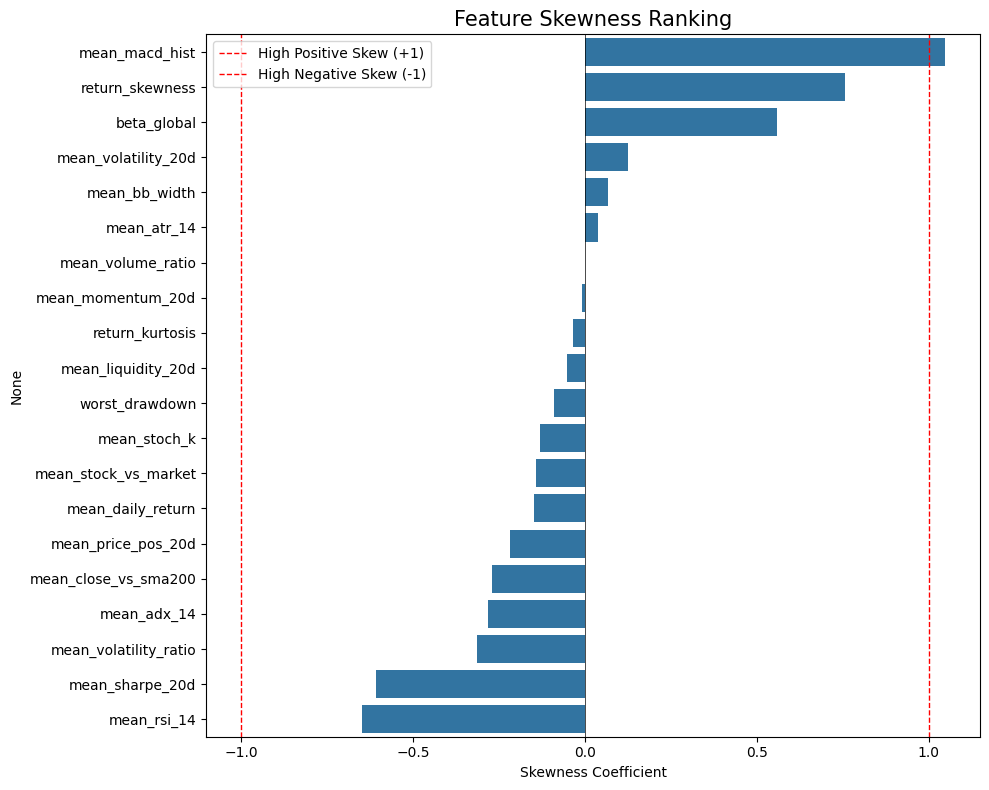

In [281]:
features_skew_transformed = skew_transformation(features, skew_data)
skew_data_transform, normal_skew_transform = skewness_analysis(features_skew_transformed, skew_threshold)

### 2.3.2 Scaling (Standardization)

In [282]:
def data_standardization(data, columns):
    scaler = StandardScaler()
    data_scaled = pd.DataFrame(scaler.fit_transform(data[columns]), columns = columns)
    
    return data_scaled

In [283]:
feature_scaled = data_standardization(features_skew_transformed, numeric_cols)

In [284]:
feature_scaled.head()

,mean_daily_return,mean_momentum_20d,mean_close_vs_sma200,mean_stock_vs_market,beta_global,mean_volatility_20d,mean_sharpe_20d,worst_drawdown,mean_atr_14,mean_volatility_ratio,mean_rsi_14,mean_adx_14,mean_macd_hist,mean_stoch_k,mean_bb_width,mean_liquidity_20d,mean_volume_ratio,mean_price_pos_20d,return_skewness,return_kurtosis
0,-0.0582,-0.1848,-0.1343,-0.0565,0.7291,0.0458,0.3545,-0.4592,0.3584,-1.2705,0.3076,-0.4144,0.2761,0.5451,0.0649,1.5460,-0.0000,0.5787,0.7832,1.0198
1,-0.0690,-0.2983,-0.0426,-0.0673,-1.0345,-0.2248,0.3080,0.7933,0.1661,0.8756,0.2401,1.3296,-0.4536,-0.0213,-0.0022,-0.3059,0.0000,-0.0882,-0.9282,0.6603
2,0.2393,0.2137,0.0473,0.2410,1.0422,0.5914,0.0804,-0.2425,0.4216,0.7957,0.0846,-0.7549,0.6846,0.3193,0.3126,1.3198,0.0000,0.4718,0.1793,-0.2778
3,0.3864,0.4718,0.5300,0.3881,0.9585,0.2165,0.4978,-0.0675,0.6564,-0.5771,0.6655,-1.0116,0.3833,0.9981,0.1429,-0.6485,-0.0000,1.0593,0.3472,0.5388
4,-0.2298,-0.2024,-0.2023,-0.2281,0.5537,0.7746,-0.1787,-1.3621,0.4149,-0.3471,-0.3449,0.6074,-0.3588,-0.7652,0.8879,-0.0186,0.0000,-0.8070,0.0827,0.3816


# 3. Feature Selection (Dimensionality Reduction)

## 3.1 (Optional) Manually remove highly correlated features

In [ ]:
# Remove highly correlated features (keep only one from each pair)
corr_matrix = feature_scaled[numeric_cols].corr()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.92:  # Very high correlation
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j]))

# Remove one feature from each highly correlated pair
features_to_remove = set()
for feat1, feat2 in high_corr_pairs:
    # Keep the one with more variance (more informative)
    if feature_scaled[feat1].var() < feature_scaled[feat2].var():
        features_to_remove.add(feat1)
    else:
        features_to_remove.add(feat2)

selected_features = [f for f in numeric_cols if f not in features_to_remove]
print(f"Selected {len(selected_features)} features from {len(numeric_cols)}")

Selected 14 features from 20


In [ ]:
# features_cleaned = feature_scaled[selected_features]
# features_cleaned.head()

## 3.2 Apply PCA for principal components

In [285]:
def pca_apply(data, n_components=0.95):
    pca = PCA(n_components=n_components)
    data_pca = pca.fit_transform(data)
    print(f"Original features: {data.shape[1]}")
    print(f"PCA components: {data_pca.shape[1]}")
    print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Explained Variance (Cumulative)")
    plt.axhline(y=n_components, color='r', linestyle='--', label=f'{n_components * 100} % Variance')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.bar(range(1, min(21, len(pca.explained_variance_ratio_) + 1)),
            pca.explained_variance_ratio_[:20])
    plt.xlabel("Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title("Top 20 Components Explained Variance")
    
    plt.tight_layout()
    plt.show()
    
    return data_pca, pca

Original features: 20
PCA components: 9
Variance explained: 97.33%


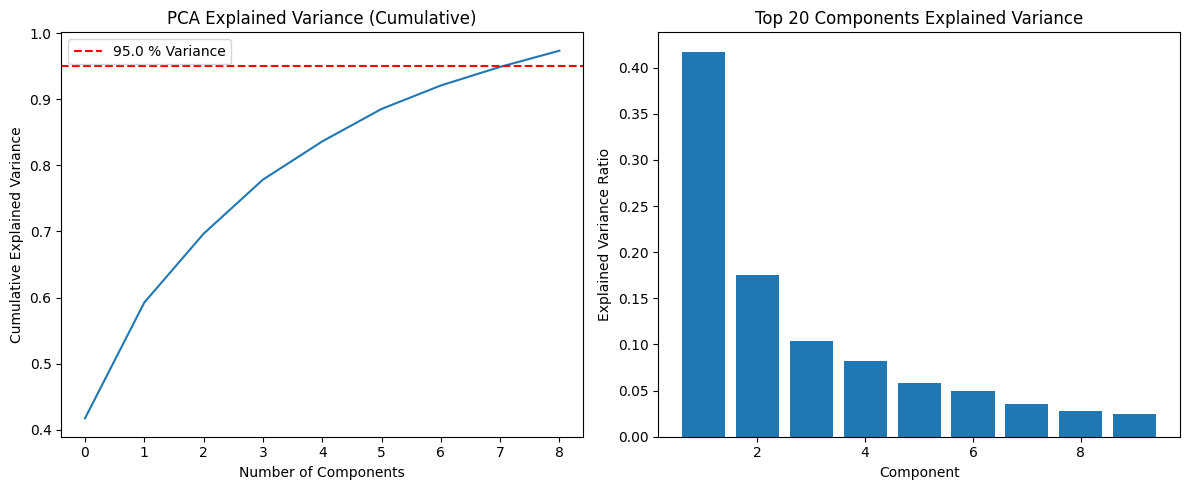

In [286]:
feature_pca, pca = pca_apply(feature_scaled, n_components=0.95)

# 4. Clustering Feasibility with Hopkins Statistic

In [287]:
def hopkins_statistic(X):
    d = X.shape[1]
    n = len(X)
    m = int(0.1 * n)
    nbrs = NearestNeighbors(n_neighbors=1).fit(X)
    
    rand_X = sample(range(0, n, 1), m)
    ujd = []
    wjd = []
    
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(np.random.uniform(np.amin(X, axis=0), np.amax(X, axis=0), d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X[rand_X[j]].reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
        
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    
    if isnan(H):
        print(ujd, wjd)
        H = 0
        
    return H

In [288]:
h_stat = hopkins_statistic(feature_pca)

In [289]:
h_stat

np.float64(0.6577101052004886)

This hopkins statistic does not return theoretically perfect result, but it's a good number for real-world practice.
Since ...

# 5. Model training

## Feature-based clustering

In [290]:
def find_optimal_clusters(data, max_k=10, random_state=42):
    k_range = range(2, max_k + 1)
    metrics = {
        'k': [],
        'silhouette': [],
        'davies_bouldin': [],
        'calinski_harabasz': [],
        'inertia': []
    }
    
    print("Testing optimal number of clusters...")
    print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18} {'Inertia':<10}")
    print("-" * 70)
    
    for k in k_range:
        pam = KMedoids(n_clusters=k, metric='euclidean', random_state=random_state, init='k-medoids++')
        labels = pam.fit_predict(data)
        
        silhouette = silhouette_score(data, labels)
        db_score = davies_bouldin_score(data, labels)
        ch_score = calinski_harabasz_score(data, labels)
        inertia = pam.inertia_
        
        metrics['k'].append(k)
        metrics['silhouette'].append(silhouette)
        metrics['davies_bouldin'].append(db_score)
        metrics['calinski_harabasz'].append(ch_score)
        metrics['inertia'].append(inertia)
        
        print(f"{k:<5} {silhouette:<12.4f} {db_score:<15.4f} {ch_score:<18.4f} {inertia:<10.2f}")
        
    metrics_df = pd.DataFrame(metrics)
    
    # Visualize metrics
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Silhouette Score (higher is better)
    axes[0, 0].plot(metrics_df['k'], metrics_df['silhouette'], marker='o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Number of Clusters (k)')
    axes[0, 0].set_ylabel('Silhouette Score')
    axes[0, 0].set_title('Silhouette Score vs k (Higher is Better)')
    axes[0, 0].grid(True, alpha=0.3)
    # axes[0, 0].axvline(x=metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'], 
    #                    color='r', linestyle='--', alpha=0.5, label='Optimal k')
    axes[0, 0].legend()
    
    # Davies-Bouldin Score (lower is better)
    axes[0, 1].plot(metrics_df['k'], metrics_df['davies_bouldin'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[0, 1].set_xlabel('Number of Clusters (k)')
    axes[0, 1].set_ylabel('Davies-Bouldin Score')
    axes[0, 1].set_title('Davies-Bouldin Score vs k (Lower is Better)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Calinski-Harabasz Score (higher is better)
    axes[1, 0].plot(metrics_df['k'], metrics_df['calinski_harabasz'], marker='o', linewidth=2, markersize=8, color='green')
    axes[1, 0].set_xlabel('Number of Clusters (k)')
    axes[1, 0].set_ylabel('Calinski-Harabasz Score')
    axes[1, 0].set_title('Calinski-Harabasz Score vs k (Higher is Better)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    # Elbow Method (Inertia)
    axes[1, 1].plot(metrics_df['k'], metrics_df['inertia'], marker='o', linewidth=2, markersize=8, color='purple')
    axes[1, 1].set_xlabel('Number of Clusters (k)')
    axes[1, 1].set_ylabel('Inertia (Within-cluster Sum of Squares)')
    axes[1, 1].set_title('Elbow Method (Inertia)')
    axes[1, 1].grid(True, alpha=0.3)
    for ax in axes.flat:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()
    
    return metrics_df

Testing optimal number of clusters...
k     Silhouette   Davies-Bouldin  Calinski-Harabasz  Inertia   
----------------------------------------------------------------------
2     0.2360       1.4803          18.5009            176.93    
3     0.1901       1.1696          9.9926             171.28    
4     0.1571       1.3278          11.3067            156.52    
5     0.1535       1.5441          10.0292            151.16    
6     0.1218       1.5444          9.8491             139.78    
7     0.1380       1.2891          10.2883            130.79    
8     0.1143       1.5891          8.7110             123.79    
9     0.1247       1.2758          9.2966             116.71    
10    0.0954       1.3160          8.0327             114.68    
11    0.1038       1.1925          8.2693             108.87    
12    0.1028       1.1283          8.0705             102.89    
13    0.0978       0.9927          8.6046             96.11     
14    0.1017       0.9358          8.8914     

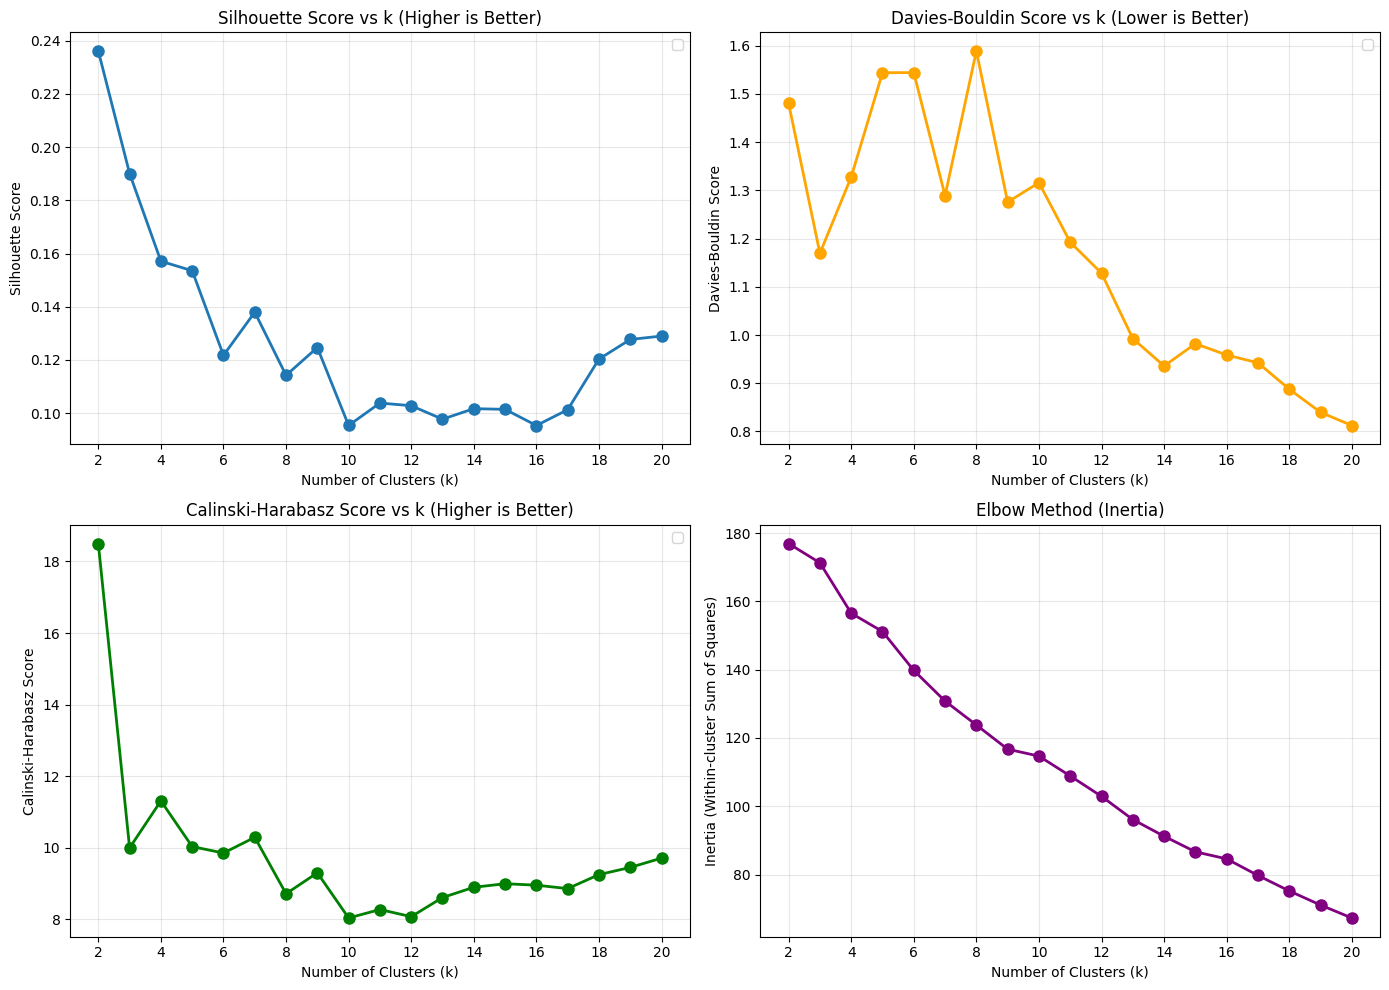

In [291]:
optimal_metrics = find_optimal_clusters(feature_pca, max_k=20)

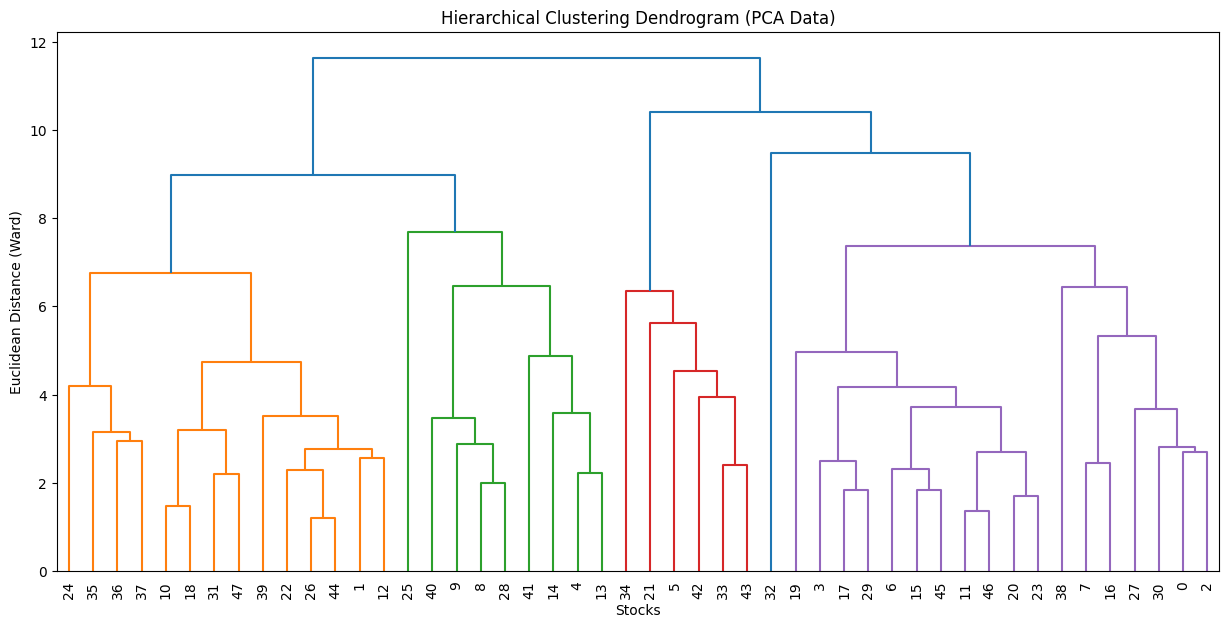

In [302]:
Z = sch.linkage(feature_pca, method='complete')

plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram (PCA Data)")
plt.xlabel("Stocks")
plt.ylabel("Euclidean Distance (Ward)")

sch.dendrogram(
    Z,
    truncate_mode='lastp',
    p=50,
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.show()

In [321]:
# Create labels for k=5
labels_5 = sch.fcluster(Z, t=5, criterion='maxclust')

if isinstance(feature_pca, np.ndarray):
    feature_pca = pd.DataFrame(feature_pca, columns=[f'PC{i+1}' for i in range(feature_pca.shape[1])])
    
# Add to dataframe
df_pca_copy = feature_pca.copy()
df_pca_copy['Cluster_HC'] = labels_5
df_pca_copy['Ticker'] = global_data['ticker'].values # Assuming global_data is aligned

# Count stocks per cluster
print(df_pca_copy['Cluster_HC'].value_counts())

# See who is in the smallest cluster (Likely Stock 32)
smallest_cluster = df_pca_copy['Cluster_HC'].value_counts().idxmin()
print(f"\nStocks in the smallest cluster ({smallest_cluster}):")
print(df_pca_copy[df_pca_copy['Cluster_HC'] == smallest_cluster]['Ticker'].tolist())

Cluster_HC
4    18
1    14
2     9
3     6
5     1
Name: count, dtype: int64

Stocks in the smallest cluster (5):
['NFLX']


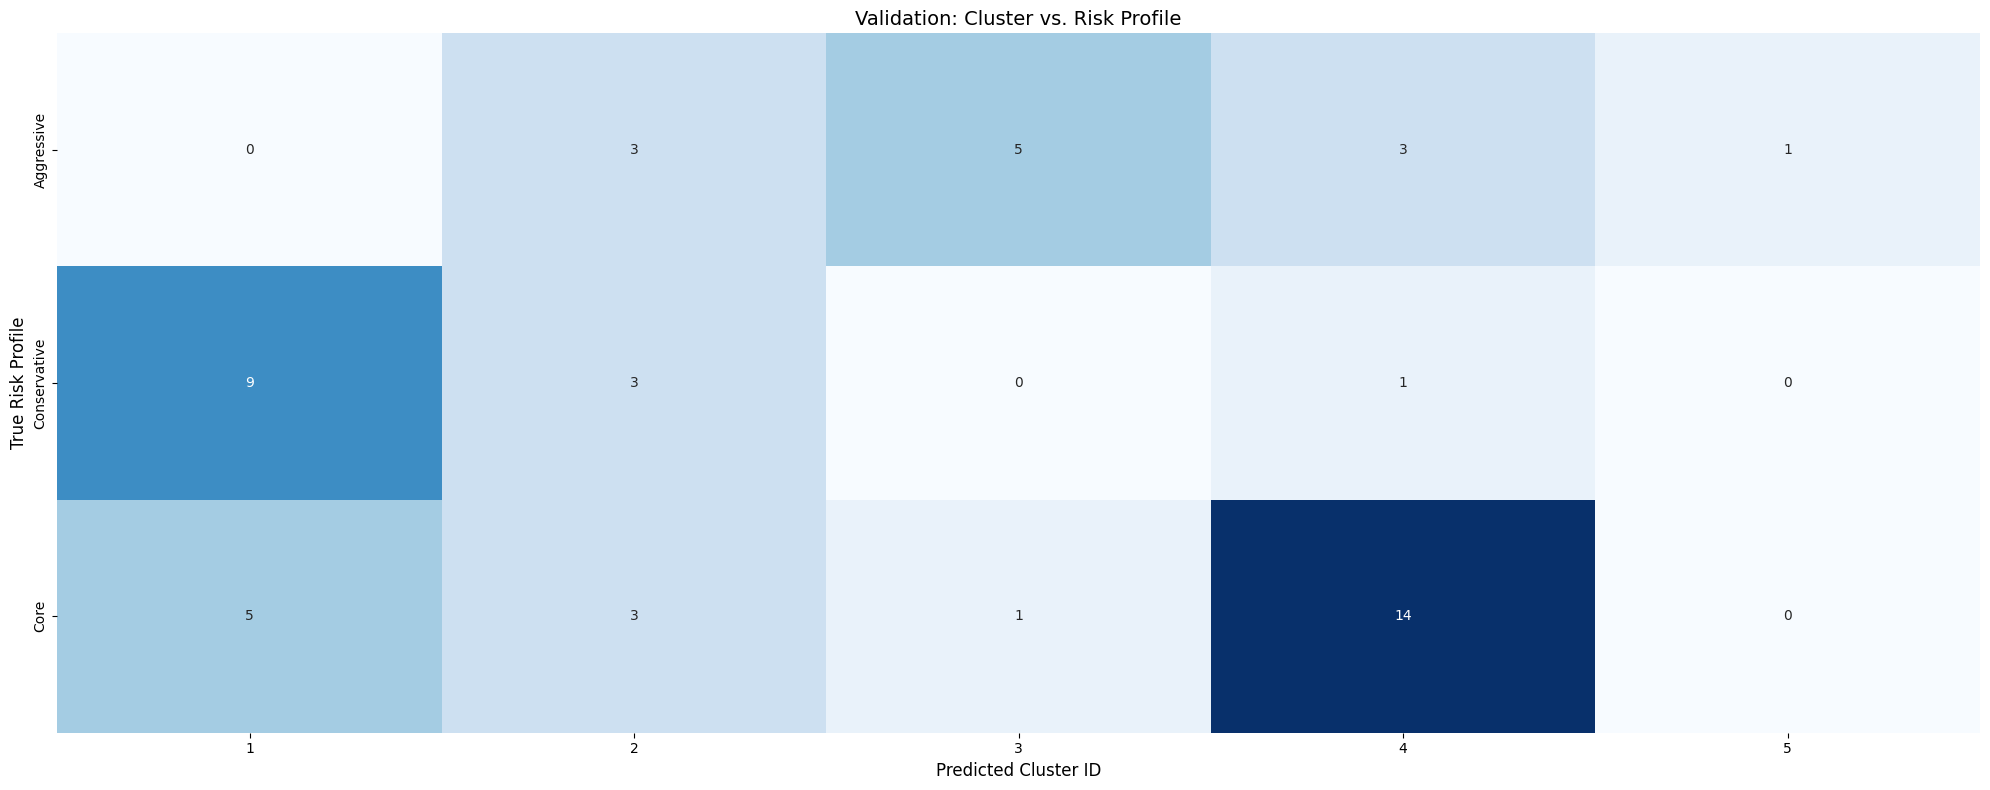

In [328]:
# 1. Map the Tickers to Profiles
# We use .map() and fillna('Other') in case a stock isn't in our dictionary
df_pca_copy['Risk_Profile'] = df_pca_copy['Ticker'].map(SYMBOL_TO_RISK_CATEGORY).fillna('Other')

# 2. Create Crosstabs (Confusion Matrices)
risk_crosstab = pd.crosstab(df_pca_copy['Risk_Profile'], df_pca_copy['Cluster_HC'])

# 3. Plotting
fig, axes = plt.subplots(1, 1, figsize=(20, 8))

# Plot A: Risk Profile Validation (The Main Event)
sns.heatmap(risk_crosstab, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Validation: Cluster vs. Risk Profile', fontsize=14)
plt.ylabel('True Risk Profile', fontsize=12)
plt.xlabel('Predicted Cluster ID', fontsize=12)

plt.tight_layout()
plt.show()

In [298]:
def apply_kmeans_clustering(data, n_clusters=5, random_state=42):
    
    kmeans_model = KMeans(
        n_clusters=n_clusters,
        init='k-means++',
        n_init=10,
        random_state=random_state,
        max_iter=300
    )
    
    labels = kmeans_model.fit_predict(data)
    
    silhouette = silhouette_score(data, labels)
    db_score = davies_bouldin_score(data, labels)
    ch_score = calinski_harabasz_score(data, labels)
    
    print(f"Silhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score:.4f} (higher is better)")

    closest_indices, _ = pairwise_distances_argmin_min(
        kmeans_model.cluster_centers_, data
    )
    
    for i, idx in enumerate(closest_indices):
        print(f"Cluster {i} Representative: {tickers[idx]}")
    
    return {
        'model': kmeans_model,
        'labels': labels,
        'medoids': closest_indices,
        'silhouette': silhouette,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score,
        'n_clusters': n_clusters
    }

In [295]:
def apply_pam_clustering(data, metric='euclidean', n_clusters=5, random_state=42):
    pam_model = KMedoids(
        n_clusters=n_clusters,
        metric=metric,
        method='pam',
        init='k-medoids++',
        random_state=random_state,
        max_iter=300
    )
    
    labels = pam_model.fit_predict(data)
    
    # Calculate quality metrics
    silhouette = silhouette_score(data, labels)
    db_score = davies_bouldin_score(data, labels)
    ch_score = calinski_harabasz_score(data, labels)
    
    print(f"Silhouette Score: {silhouette:.4f} (higher is better, range: -1 to 1)")
    print(f"Davies-Bouldin Score: {db_score:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {ch_score:.4f} (higher is better)")
    
    # Get medoids (representative stocks for each cluster)
    medoids = pam_model.medoid_indices_
    for medoid in medoids:
        print(f"Medoids (representative stocks): {tickers[medoid]}")
    
    return {
        'model': pam_model,
        'labels': labels,
        'medoids': medoids,
        'silhouette': silhouette,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score,
        'n_clusters': n_clusters
    }

In [296]:
def cluster_loop(data, methods = ['k-means', 'pam'], metrics=['euclidean', 'manhattan', 'cosine'], n_clusters=range(2, 10)):
    cluster_loop = {}
    if isinstance(n_clusters, int):
        n_clusters = [n_clusters]
    for method in methods:
        if method == 'k-means':
            for n_cluster in n_clusters:
                for metric in metrics:
                    column = f"kmeans_{metric}_{n_cluster}"
                    cluster_loop[column] = apply_kmeans_clustering(data, n_clusters=n_cluster)
        if method == 'pam':    
            for n_cluster in n_clusters:
                for metric in metrics:
                    column = f"pam_{metric}_{n_cluster}"
                    cluster_loop[column] = apply_pam_clustering(data, metric=metric, n_clusters=n_cluster)
    return cluster_loop

In [303]:
clusters = cluster_loop(feature_pca, n_clusters=3)

Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.2057 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.5516 (lower is better)
Calinski-Harabasz Score: 16.4859 (higher is better)
Cluster 0 Representative: TSM
Cluster 1 Representative: NEE
Cluster 2 Representative: WMT
Silhouette Score: 0.1707 (higher is better, range: -1 to 1)
Davies-Bouldin Score: 1.6313 (lower is better)
Calinski-Harabasz Score: 14.1861 (higher is better)
Medoids (representative stocks): CVX
Medoids (representative stocks): MS
Medoids (representati

In [ ]:
def visualize_clusters_pca(data_pca_9d, labels, tickers, n_clusters):
    from mpl_toolkits.mplot3d import Axes3D
    
    # Project to 2D for visualization
    pca_2d = PCA(n_components=2)
    data_2d = pca_2d.fit_transform(data_pca_9d)
    
    # Project to 3D for visualization
    pca_3d = PCA(n_components=3)
    data_3d = pca_3d.fit_transform(data_pca_9d)
    
    # Create color palette
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
    
    # 2D Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 2D scatter plot
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        axes[0].scatter(
            data_2d[cluster_mask, 0],
            data_2d[cluster_mask, 1],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id + 1}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=1.5
        )
    
    axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    axes[0].set_title('PAM Clusters - 2D PCA Projection', fontsize=14, fontweight='bold')
    axes[0].legend(loc='best', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Add ticker labels (optional - can be cluttered with 48 stocks)
    # Uncomment if you want to see ticker names
    for i, ticker in enumerate(tickers):
        axes[0].annotate(ticker, (data_2d[i, 0], data_2d[i, 1]), fontsize=6)
    
    # 3D Visualization
    ax_3d = fig.add_subplot(122, projection='3d')
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        ax_3d.scatter(
            data_3d[cluster_mask, 0],
            data_3d[cluster_mask, 1],
            data_3d[cluster_mask, 2],
            c=[colors[cluster_id]],
            label=f'Cluster {cluster_id + 1}',
            alpha=0.7,
            s=100,
            edgecolors='black',
            linewidth=1.5
        )
    
    ax_3d.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%} variance)', fontsize=10)
    ax_3d.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%} variance)', fontsize=10)
    ax_3d.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%} variance)', fontsize=10)
    ax_3d.set_title('PAM Clusters - 3D PCA Projection', fontsize=14, fontweight='bold')
    ax_3d.legend(loc='best', fontsize=10)
    
    plt.tight_layout()
    # plt.savefig(f'{output_dir}/pam_clusters_pca_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return pca_2d, pca_3d, data_2d, data_3d

In [305]:
def visualize_all_clusters(clusters, data_pca, tickers):
    print(f"Visualizing {len(clusters)} clustering results...")
    print("="*80)
    
    for method_name, cluster_result in clusters.items():
        print(f"\nVisualizing: {method_name}")
        print("-" * 80)
        
        # Extract clustering info
        labels = cluster_result['labels']
        n_clusters = cluster_result.get('n_clusters', len(np.unique(labels)))
        
        # Print metrics
        print(f"Silhouette Score: {cluster_result['silhouette']:.4f}")
        print(f"Davies-Bouldin Score: {cluster_result['davies_bouldin']:.4f}")
        print(f"Calinski-Harabasz Score: {cluster_result['calinski_harabasz']:.4f}")
        
        # Visualize
        visualize_clusters_pca(
            data_pca_9d=data_pca,
            labels=labels,
            tickers=tickers,
            n_clusters=n_clusters
        )
        
        # Add a small delay to see each plot (optional)
        # plt.pause(0.5)
    
    print("\n" + "="*80)
    print("All visualizations complete!")
    print("="*80)

# Usage:
# visualize_all_clusters(clusters, feature_pca, tickers)

Visualizing 6 clustering results...

Visualizing: kmeans_euclidean_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


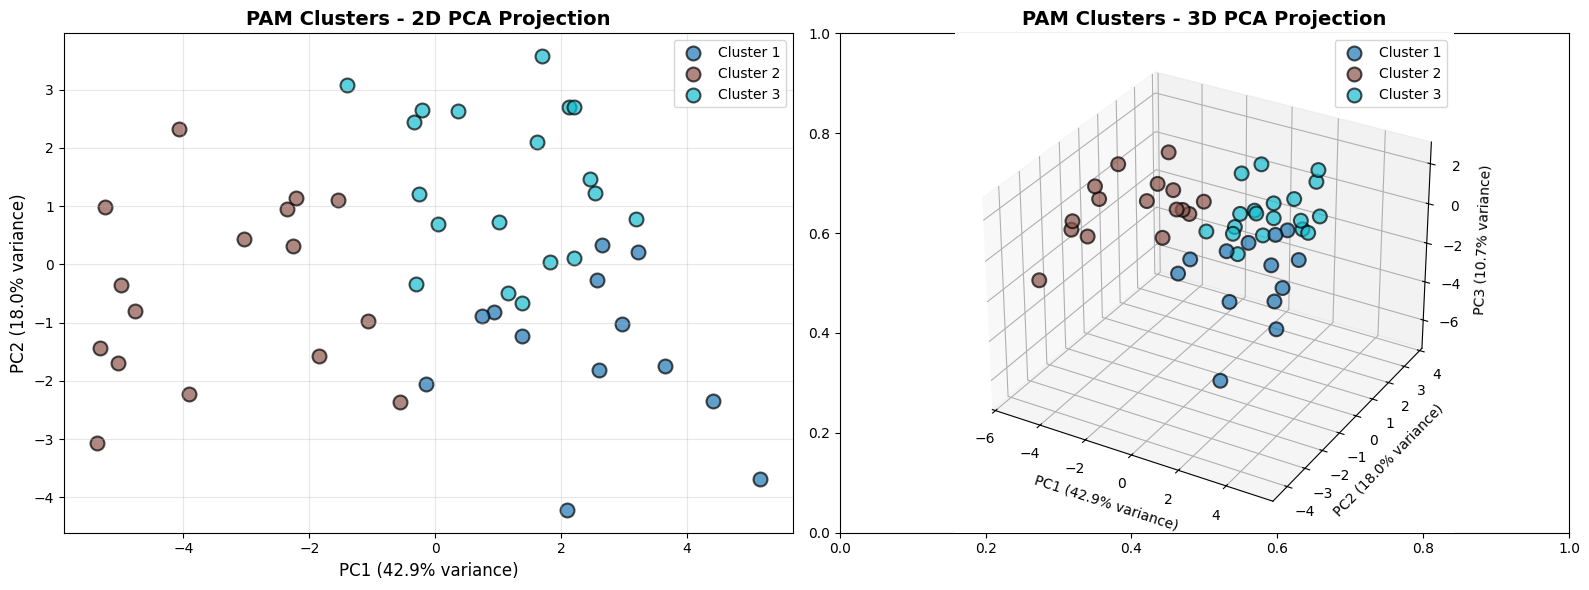


Visualizing: kmeans_manhattan_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


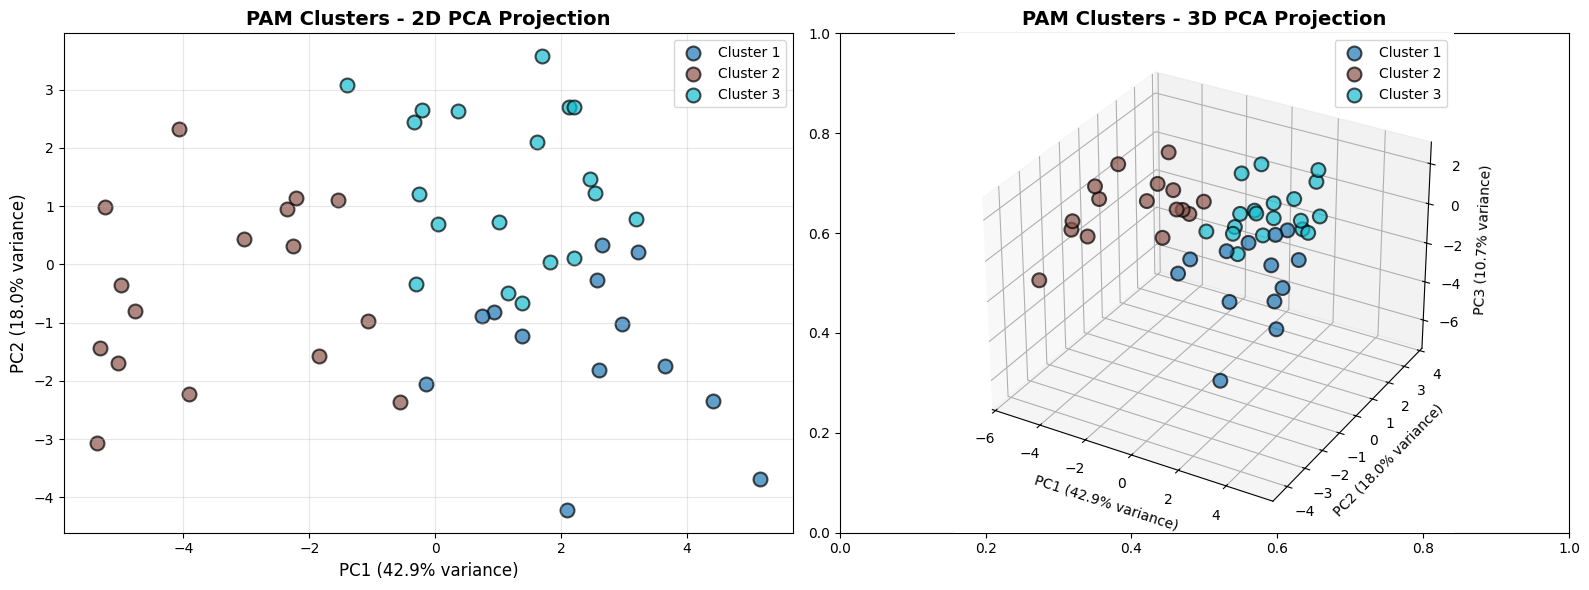


Visualizing: kmeans_cosine_3
--------------------------------------------------------------------------------
Silhouette Score: 0.2057
Davies-Bouldin Score: 1.5516
Calinski-Harabasz Score: 16.4859


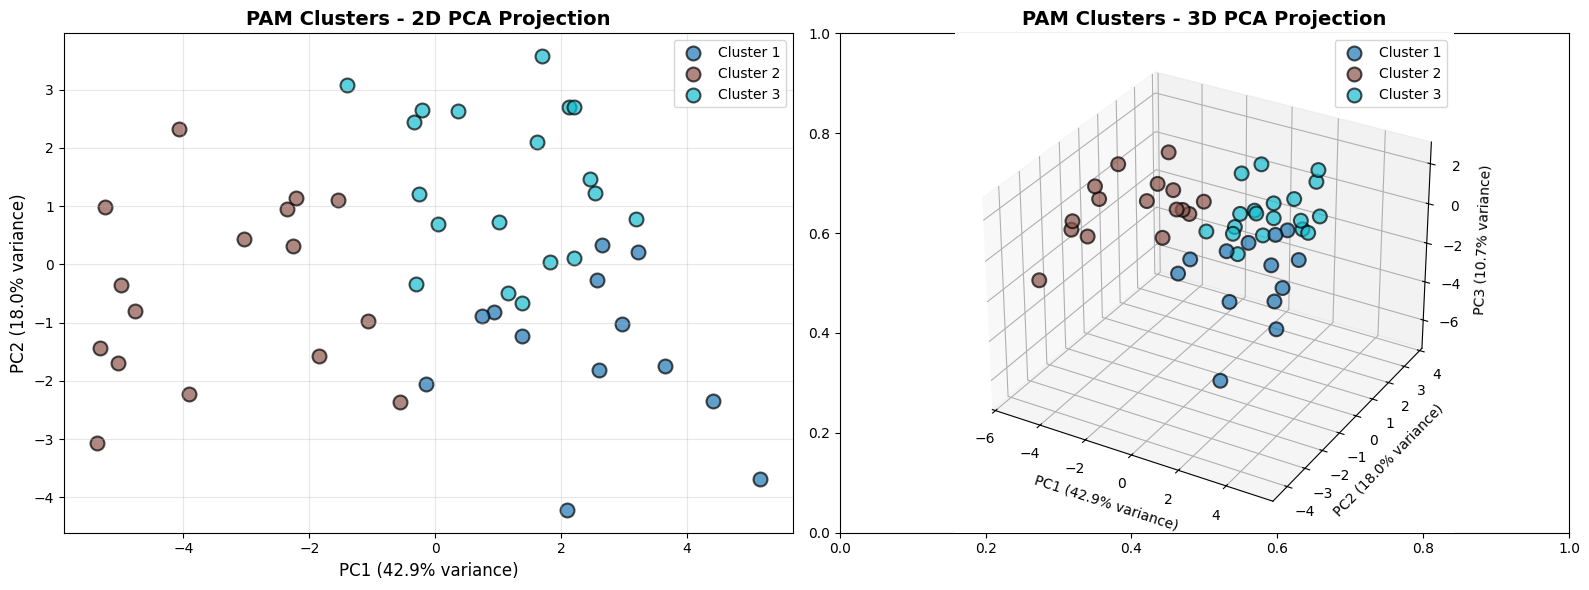


Visualizing: pam_euclidean_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1707
Davies-Bouldin Score: 1.6313
Calinski-Harabasz Score: 14.1861


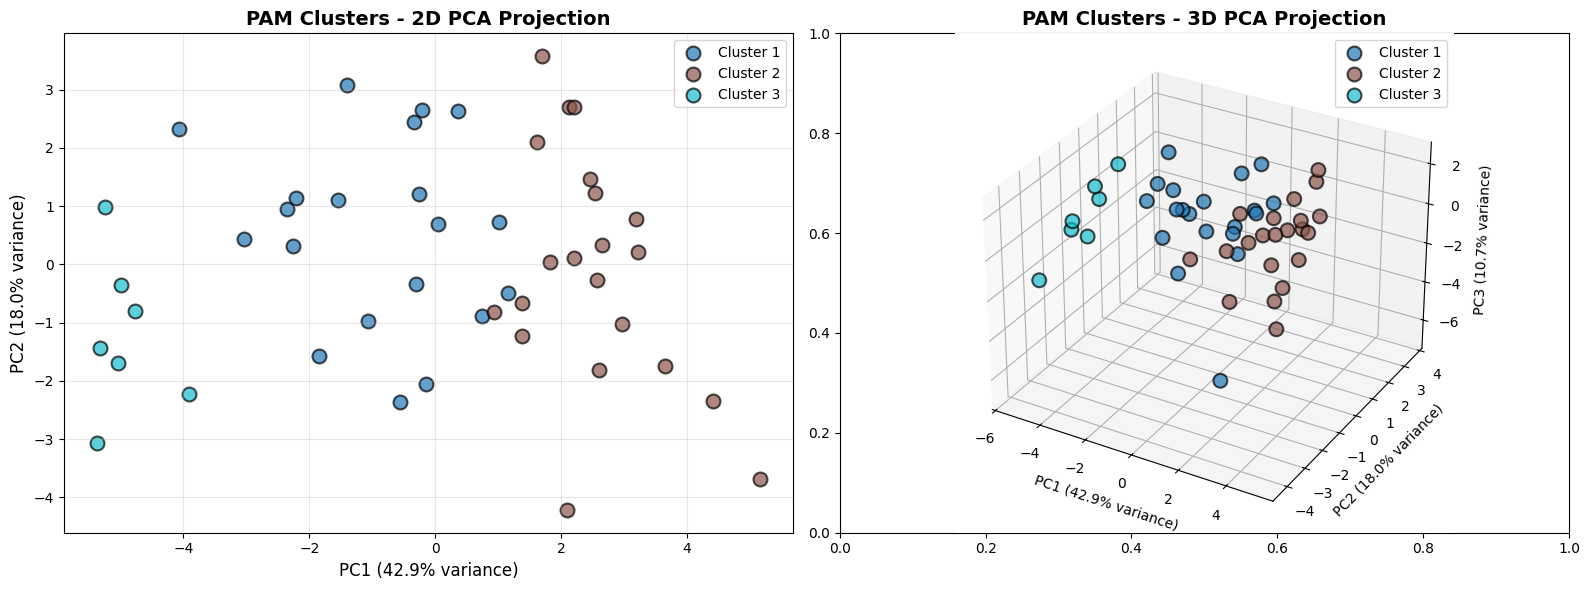


Visualizing: pam_manhattan_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1537
Davies-Bouldin Score: 1.6803
Calinski-Harabasz Score: 14.3013


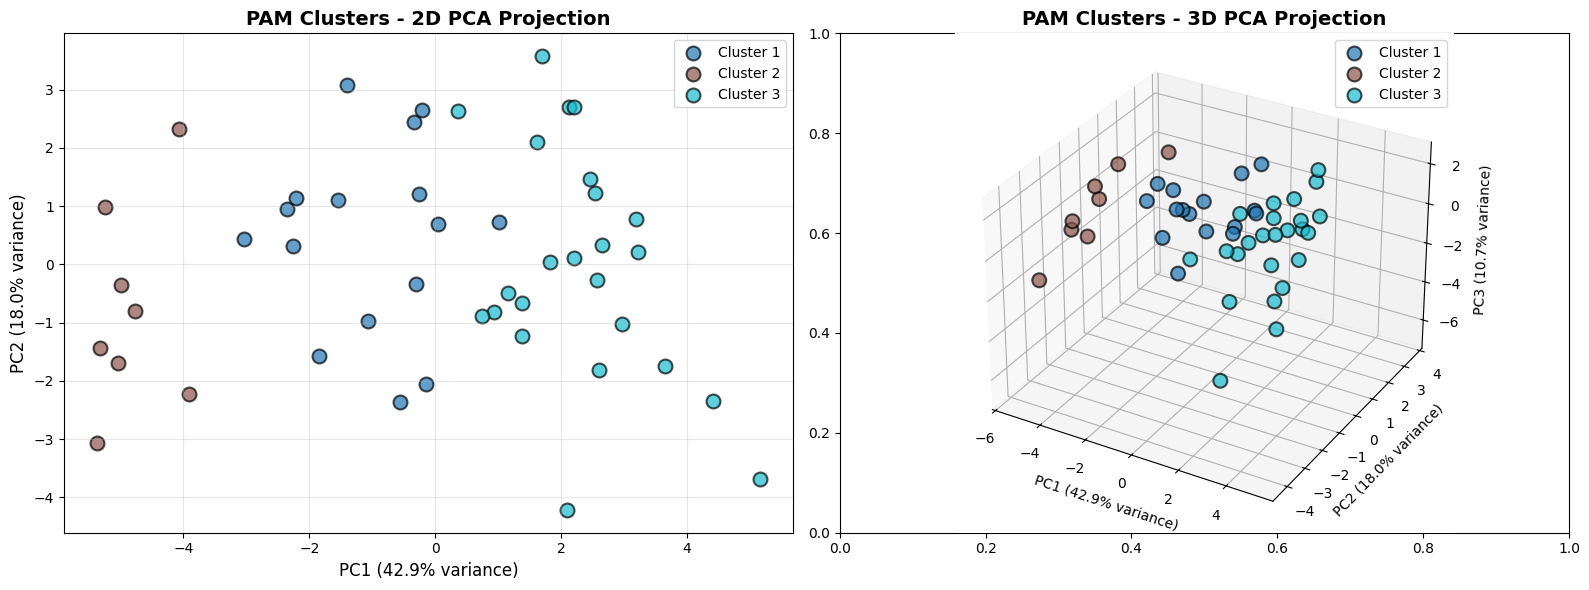


Visualizing: pam_cosine_3
--------------------------------------------------------------------------------
Silhouette Score: 0.1741
Davies-Bouldin Score: 1.4276
Calinski-Harabasz Score: 14.5730


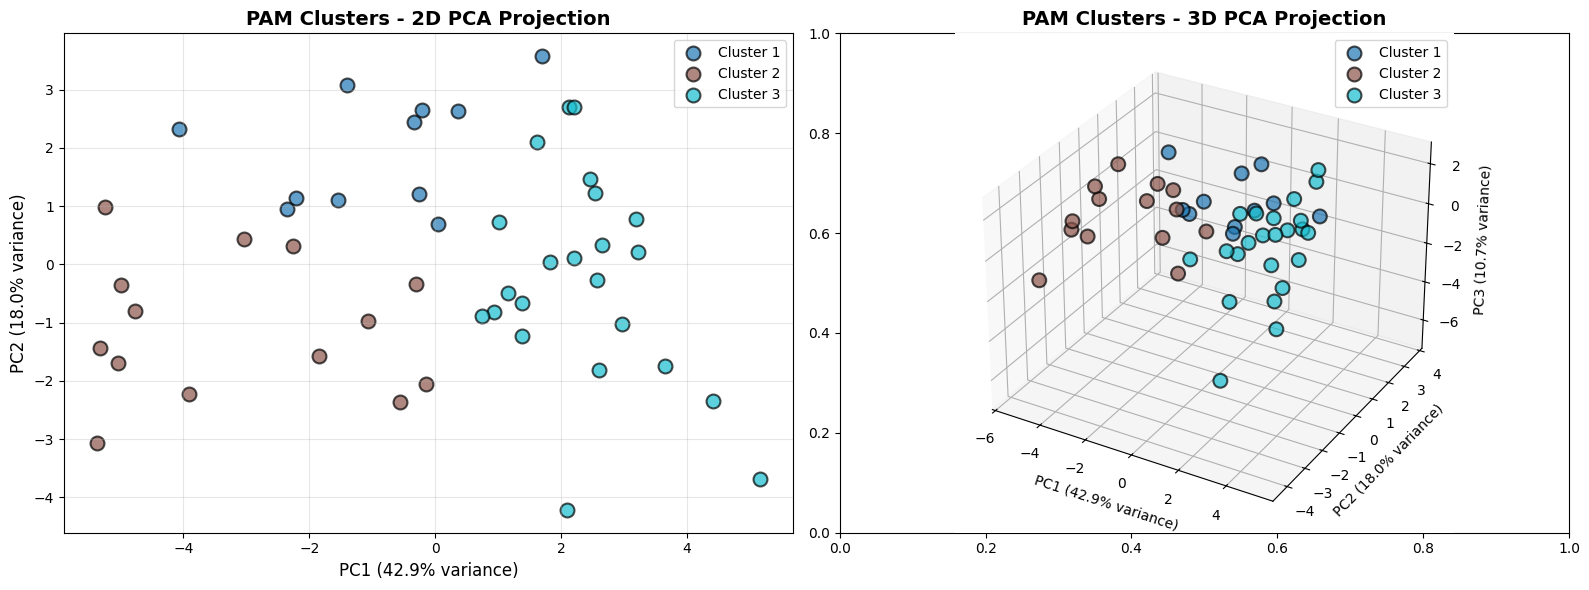


All visualizations complete!


In [306]:
visualize_all_clusters(clusters, feature_pca, tickers)

In [329]:
def compare_clustering_results(clusters, data=None):
    
    method_names = list(clusters.keys())
    n_methods = len(method_names)
    
    # Initialize comparison matrices
    ari_matrix = np.zeros((n_methods, n_methods))
    nmi_matrix = np.zeros((n_methods, n_methods))
    homogeneity_matrix = np.zeros((n_methods, n_methods))
    completeness_matrix = np.zeros((n_methods, n_methods))
    v_measure_matrix = np.zeros((n_methods, n_methods))
    fmi_matrix = np.zeros((n_methods, n_methods))  # Fowlkes-Mallows Index
    
    comparison_results = []
    
    # Extract all labels
    all_labels = {}
    for name in method_names:
        all_labels[name] = clusters[name]['labels']
    
    for i, name1 in enumerate(method_names):
        labels1 = all_labels[name1]
        
        for j, name2 in enumerate(method_names):
            labels2 = all_labels[name2]
            
            # Skip self-comparison (will be 1.0)
            if i == j:
                ari = 1.0
                nmi = 1.0
                homogeneity = 1.0
                completeness = 1.0
                v_measure = 1.0
                fmi = 1.0
            else:
                ari = adjusted_rand_score(labels1, labels2)
                nmi = normalized_mutual_info_score(labels1, labels2)
                homogeneity = homogeneity_score(labels1, labels2)
                completeness = completeness_score(labels1, labels2)
                v_measure = v_measure_score(labels1, labels2)
                fmi = fowlkes_mallows_score(labels1, labels2)
            
            # Store in matrices
            ari_matrix[i, j] = ari
            nmi_matrix[i, j] = nmi
            homogeneity_matrix[i, j] = homogeneity
            completeness_matrix[i, j] = completeness
            v_measure_matrix[i, j] = v_measure
            fmi_matrix[i, j] = fmi
            
            # Store detailed results
            if i < j:  # Only store upper triangle to avoid duplicates
                comparison_results.append({
                    'method1': name1,
                    'method2': name2,
                    'ari': ari,
                    'nmi': nmi,
                    'homogeneity': homogeneity,
                    'completeness': completeness,
                    'v_measure': v_measure,
                    'fowlkes_mallows': fmi
                })
    
    # Create DataFrames
    ari_df = pd.DataFrame(ari_matrix, index=method_names, columns=method_names)
    nmi_df = pd.DataFrame(nmi_matrix, index=method_names, columns=method_names)
    comparison_df = pd.DataFrame(comparison_results)
    
    # Print summary
    print("\n" + "-"*80)
    print("AGREEMENT INDICES SUMMARY")
    print("-"*80)
    print("\nAdjusted Rand Index (ARI) - Range: [-1, 1], 1.0 = perfect match")
    print(ari_df.round(3))
    
    print("\nNormalized Mutual Information (NMI) - Range: [0, 1], 1.0 = perfect match")
    print(nmi_df.round(3))
    
    print("\nDetailed Pairwise Comparisons:")
    print(comparison_df.round(4).to_string(index=False))
    
    # Find most similar and most different pairs
    print("\n" + "-"*80)
    print("MOST SIMILAR CLUSTERING PAIRS (Top 5 by ARI)")
    print("-"*80)
    top_similar = comparison_df.nlargest(5, 'ari')[['method1', 'method2', 'ari', 'nmi']]
    print(top_similar.to_string(index=False))
    
    print("\n" + "-"*80)
    print("MOST DIFFERENT CLUSTERING PAIRS (Bottom 5 by ARI)")
    print("-"*80)
    top_different = comparison_df.nsmallest(5, 'ari')[['method1', 'method2', 'ari', 'nmi']]
    print(top_different.to_string(index=False))
    
    # Visualize comparison matrices
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    metrics = [
        ('Adjusted Rand Index (ARI)', ari_df, 'Blues'),
        ('Normalized Mutual Info (NMI)', nmi_df, 'Greens'),
        ('Homogeneity', pd.DataFrame(homogeneity_matrix, index=method_names, columns=method_names), 'Oranges'),
        ('Completeness', pd.DataFrame(completeness_matrix, index=method_names, columns=method_names), 'Purples'),
        ('V-Measure', pd.DataFrame(v_measure_matrix, index=method_names, columns=method_names), 'Reds'),
        ('Fowlkes-Mallows Index', pd.DataFrame(fmi_matrix, index=method_names, columns=method_names), 'YlOrBr')
    ]
    
    for idx, (title, matrix_df, cmap) in enumerate(metrics):
        row = idx // 3
        col = idx % 3
        ax = axes[row, col]
        
        sns.heatmap(
            matrix_df,
            annot=True,
            fmt='.3f',
            cmap=cmap,
            square=True,
            cbar_kws={'label': 'Score'},
            ax=ax,
            vmin=0,
            vmax=1
        )
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'ari_matrix': ari_df,
        'nmi_matrix': nmi_df,
        'comparison_df': comparison_df,
        'homogeneity_matrix': pd.DataFrame(homogeneity_matrix, index=method_names, columns=method_names),
        'completeness_matrix': pd.DataFrame(completeness_matrix, index=method_names, columns=method_names),
        'v_measure_matrix': pd.DataFrame(v_measure_matrix, index=method_names, columns=method_names),
        'fmi_matrix': pd.DataFrame(fmi_matrix, index=method_names, columns=method_names)
    }

# ============================================
# 2. WITHIN-CLUSTER & BETWEEN-CLUSTER STATISTICS
# ============================================

def compute_cluster_statistics(clusters, data):
    all_statistics = []
    
    for method_name, cluster_result in clusters.items():
        labels = cluster_result['labels']
        n_clusters = cluster_result.get('n_clusters', len(np.unique(labels)))
        unique_labels = np.unique(labels)
        
        print(f"\n{method_name}:")
        print("-" * 80)
        
        # Calculate overall centroid
        overall_centroid = np.mean(data, axis=0)
        
        # Initialize statistics
        within_cluster_ss = []  # Within-cluster sum of squares
        between_cluster_ss = []  # Between-cluster sum of squares
        within_cluster_var = []  # Within-cluster variance
        between_cluster_var = []  # Between-cluster variance
        cluster_sizes = []
        cluster_centroids = []
        
        total_within_ss = 0
        total_between_ss = 0
        
        for cluster_id in unique_labels:
            cluster_mask = labels == cluster_id
            cluster_data = data[cluster_mask]
            cluster_size = np.sum(cluster_mask)
            cluster_sizes.append(cluster_size)
            
            # Cluster centroid
            cluster_centroid = np.mean(cluster_data, axis=0)
            cluster_centroids.append(cluster_centroid)
            
            # Within-cluster sum of squares (WCSS)
            within_ss = np.sum((cluster_data - cluster_centroid) ** 2)
            within_cluster_ss.append(within_ss)
            total_within_ss += within_ss
            
            # Within-cluster variance
            if cluster_size > 1:
                cluster_var = np.var(cluster_data, axis=0, ddof=1)  # Sample variance
                within_cluster_var.append(np.mean(cluster_var))
            else:
                within_cluster_var.append(0.0)
            
            # Between-cluster sum of squares (BCSS)
            # Distance from cluster centroid to overall centroid
            between_ss = cluster_size * np.sum((cluster_centroid - overall_centroid) ** 2)
            between_cluster_ss.append(between_ss)
            total_between_ss += between_ss
        
        # Between-cluster variance
        if len(cluster_centroids) > 1:
            centroids_array = np.array(cluster_centroids)
            between_cluster_var_value = np.var(centroids_array, axis=0, ddof=1)
            between_cluster_var_avg = np.mean(between_cluster_var_value)
        else:
            between_cluster_var_avg = 0.0
        
        # Total sum of squares (TSS)
        total_ss = total_within_ss + total_between_ss
        
        # Calculate ratios
        within_ss_ratio = total_within_ss / total_ss if total_ss > 0 else 0
        between_ss_ratio = total_between_ss / total_ss if total_ss > 0 else 0
        
        # Silhouette score components (average)
        avg_within_cluster_distance = []
        avg_between_cluster_distance = []
        
        for cluster_id in unique_labels:
            cluster_mask = labels == cluster_id
            cluster_data = data[cluster_mask]
            
            if len(cluster_data) > 1:
                # Average distance within cluster
                cluster_distances = pdist(cluster_data, metric='euclidean')
                avg_within_cluster_distance.append(np.mean(cluster_distances))
            else:
                avg_within_cluster_distance.append(0.0)
            
            # Average distance to nearest other cluster
            other_clusters = [c for c in unique_labels if c != cluster_id]
            if other_clusters:
                min_distances = []
                for other_id in other_clusters:
                    other_mask = labels == other_id
                    other_data = data[other_mask]
                    
                    # Distance from this cluster to other cluster
                    distances = []
                    for point in cluster_data:
                        dists_to_other = np.sqrt(np.sum((other_data - point) ** 2, axis=1))
                        distances.append(np.min(dists_to_other))
                    min_distances.append(np.mean(distances))
                
                avg_between_cluster_distance.append(np.min(min_distances))
            else:
                avg_between_cluster_distance.append(0.0)
        
        # Summary statistics
        stats = {
            'method': method_name,
            'n_clusters': n_clusters,
            'total_within_ss': total_within_ss,
            'total_between_ss': total_between_ss,
            'total_ss': total_ss,
            'within_ss_ratio': within_ss_ratio,
            'between_ss_ratio': between_ss_ratio,
            'avg_within_cluster_ss': np.mean(within_cluster_ss),
            'avg_between_cluster_ss': np.mean(between_cluster_ss),
            'avg_within_cluster_var': np.mean(within_cluster_var),
            'between_cluster_var': between_cluster_var_avg,
            'avg_within_cluster_distance': np.mean(avg_within_cluster_distance),
            'avg_between_cluster_distance': np.mean(avg_between_cluster_distance),
            'separation_ratio': np.mean(avg_between_cluster_distance) / np.mean(avg_within_cluster_distance) 
                               if np.mean(avg_within_cluster_distance) > 0 else 0,
            'cluster_sizes': cluster_sizes,
            'cluster_sizes_std': np.std(cluster_sizes),
            'cluster_sizes_min': np.min(cluster_sizes),
            'cluster_sizes_max': np.max(cluster_sizes)
        }
        
        all_statistics.append(stats)
        
        # Print summary
        print(f"  Number of clusters: {n_clusters}")
        print(f"  Total Within-Cluster SS: {total_within_ss:.2f} ({within_ss_ratio:.1%})")
        print(f"  Total Between-Cluster SS: {total_between_ss:.2f} ({between_ss_ratio:.1%})")
        print(f"  Average Within-Cluster SS: {np.mean(within_cluster_ss):.2f}")
        print(f"  Average Between-Cluster SS: {np.mean(between_cluster_ss):.2f}")
        print(f"  Average Within-Cluster Variance: {np.mean(within_cluster_var):.4f}")
        print(f"  Between-Cluster Variance: {between_cluster_var_avg:.4f}")
        print(f"  Average Within-Cluster Distance: {np.mean(avg_within_cluster_distance):.4f}")
        print(f"  Average Between-Cluster Distance: {np.mean(avg_between_cluster_distance):.4f}")
        print(f"  Separation Ratio (Between/Within): {stats['separation_ratio']:.4f}")
        print(f"  Cluster Sizes: {cluster_sizes} (std: {np.std(cluster_sizes):.2f})")
    
    # Create summary DataFrame
    stats_df = pd.DataFrame(all_statistics)
    
    # Print overall comparison
    print("\n" + "="*80)
    print("COMPARATIVE SUMMARY")
    print("="*80)
    
    # Sort by different criteria
    print("\nBest Separation (Highest Separation Ratio):")
    print(stats_df.nlargest(5, 'separation_ratio')[['method', 'separation_ratio', 'within_ss_ratio', 'between_ss_ratio']].to_string(index=False))
    
    print("\nLowest Within-Cluster SS (Most Compact Clusters):")
    print(stats_df.nsmallest(5, 'total_within_ss')[['method', 'total_within_ss', 'within_ss_ratio']].to_string(index=False))
    
    print("\nHighest Between-Cluster SS (Most Separated Clusters):")
    print(stats_df.nlargest(5, 'total_between_ss')[['method', 'total_between_ss', 'between_ss_ratio']].to_string(index=False))
    
    print("\nMost Balanced Cluster Sizes (Lowest Std):")
    print(stats_df.nsmallest(5, 'cluster_sizes_std')[['method', 'n_clusters', 'cluster_sizes_std', 'cluster_sizes_min', 'cluster_sizes_max']].to_string(index=False))
    
    # Visualize statistics
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # 1. Within vs Between SS Ratio
    ax = axes[0, 0]
    ax.scatter(stats_df['within_ss_ratio'], stats_df['between_ss_ratio'], s=100, alpha=0.6)
    for idx, row in stats_df.iterrows():
        ax.annotate(row['method'], (row['within_ss_ratio'], row['between_ss_ratio']), 
                   fontsize=7, alpha=0.7)
    ax.set_xlabel('Within-Cluster SS Ratio')
    ax.set_ylabel('Between-Cluster SS Ratio')
    ax.set_title('Within vs Between SS Ratio')
    ax.grid(True, alpha=0.3)
    ax.axline((0.5, 0.5), slope=1, color='r', linestyle='--', alpha=0.5)
    
    # 2. Separation Ratio
    ax = axes[0, 1]
    stats_df_sorted = stats_df.sort_values('separation_ratio', ascending=True)
    ax.barh(range(len(stats_df_sorted)), stats_df_sorted['separation_ratio'])
    ax.set_yticks(range(len(stats_df_sorted)))
    ax.set_yticklabels(stats_df_sorted['method'], fontsize=8)
    ax.set_xlabel('Separation Ratio (Between/Within Distance)')
    ax.set_title('Cluster Separation (Higher is Better)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 3. Total Within SS
    ax = axes[0, 2]
    stats_df_sorted = stats_df.sort_values('total_within_ss', ascending=True)
    ax.barh(range(len(stats_df_sorted)), stats_df_sorted['total_within_ss'])
    ax.set_yticks(range(len(stats_df_sorted)))
    ax.set_yticklabels(stats_df_sorted['method'], fontsize=8)
    ax.set_xlabel('Total Within-Cluster SS')
    ax.set_title('Cluster Compactness (Lower is Better)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 4. Cluster Size Balance
    ax = axes[1, 0]
    ax.scatter(stats_df['n_clusters'], stats_df['cluster_sizes_std'], s=100, alpha=0.6)
    for idx, row in stats_df.iterrows():
        ax.annotate(row['method'], (row['n_clusters'], row['cluster_sizes_std']), 
                   fontsize=7, alpha=0.7)
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Cluster Size Std Dev')
    ax.set_title('Cluster Size Balance (Lower Std = More Balanced)')
    ax.grid(True, alpha=0.3)
    
    # 5. Within-Cluster Variance
    ax = axes[1, 1]
    stats_df_sorted = stats_df.sort_values('avg_within_cluster_var', ascending=True)
    ax.barh(range(len(stats_df_sorted)), stats_df_sorted['avg_within_cluster_var'])
    ax.set_yticks(range(len(stats_df_sorted)))
    ax.set_yticklabels(stats_df_sorted['method'], fontsize=8)
    ax.set_xlabel('Average Within-Cluster Variance')
    ax.set_title('Cluster Homogeneity (Lower is Better)')
    ax.grid(True, alpha=0.3, axis='x')
    
    # 6. Between-Cluster Variance
    ax = axes[1, 2]
    stats_df_sorted = stats_df.sort_values('between_cluster_var', ascending=False)
    ax.barh(range(len(stats_df_sorted)), stats_df_sorted['between_cluster_var'])
    ax.set_yticks(range(len(stats_df_sorted)))
    ax.set_yticklabels(stats_df_sorted['method'], fontsize=8)
    ax.set_xlabel('Between-Cluster Variance')
    ax.set_title('Cluster Separation (Higher is Better)')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    return stats_df

# ============================================
# COMPLETE ANALYSIS FUNCTION
# ============================================

def complete_clustering_analysis(clusters, data, tickers=None):
    
    # 1. Agreement indices comparison
    print("\n" + "="*80)
    print("PART 1: AGREEMENT INDICES COMPARISON")
    print("="*80)
    agreement_results = compare_clustering_results(clusters, data=data)
    
    # 2. Cluster statistics
    print("\n" + "="*80)
    print("PART 2: WITHIN/BETWEEN CLUSTER STATISTICS")
    print("="*80)
    stats_results = compute_cluster_statistics(clusters, data)
    
    # 3. Combined summary
    print("\n" + "="*80)
    print("COMBINED SUMMARY")
    print("="*80)
    
    # Merge agreement and statistics
    summary_df = stats_results.copy()
    
    # Add average ARI with other methods
    method_names = list(clusters.keys())
    avg_ari = []
    for method in method_names:
        ari_values = []
        for other_method in method_names:
            if method != other_method:
                ari = agreement_results['ari_matrix'].loc[method, other_method]
                ari_values.append(ari)
        avg_ari.append(np.mean(ari_values) if ari_values else 0)
    
    summary_df['avg_ari_with_others'] = avg_ari
    
    print("\nTop 5 Methods by Separation Ratio:")
    print(summary_df.nlargest(5, 'separation_ratio')[['method', 'separation_ratio', 'avg_ari_with_others', 'total_within_ss']].to_string(index=False))
    
    print("\nTop 5 Methods by Average ARI (Agreement with Others):")
    print(summary_df.nlargest(5, 'avg_ari_with_others')[['method', 'avg_ari_with_others', 'separation_ratio', 'total_within_ss']].to_string(index=False))
    
    return {
        'agreement': agreement_results,
        'statistics': stats_results,
        'summary': summary_df
    }


PART 1: AGREEMENT INDICES COMPARISON

--------------------------------------------------------------------------------
AGREEMENT INDICES SUMMARY
--------------------------------------------------------------------------------

Adjusted Rand Index (ARI) - Range: [-1, 1], 1.0 = perfect match
                    kmeans_euclidean_3  kmeans_manhattan_3  kmeans_cosine_3  \
kmeans_euclidean_3              1.0000              1.0000           1.0000   
kmeans_manhattan_3              1.0000              1.0000           1.0000   
kmeans_cosine_3                 1.0000              1.0000           1.0000   
pam_euclidean_3                 0.2190              0.2190           0.2190   
pam_manhattan_3                 0.2730              0.2730           0.2730   
pam_cosine_3                    0.3290              0.3290           0.3290   

                    pam_euclidean_3  pam_manhattan_3  pam_cosine_3  
kmeans_euclidean_3           0.2190           0.2730        0.3290  
kmeans_manhattan

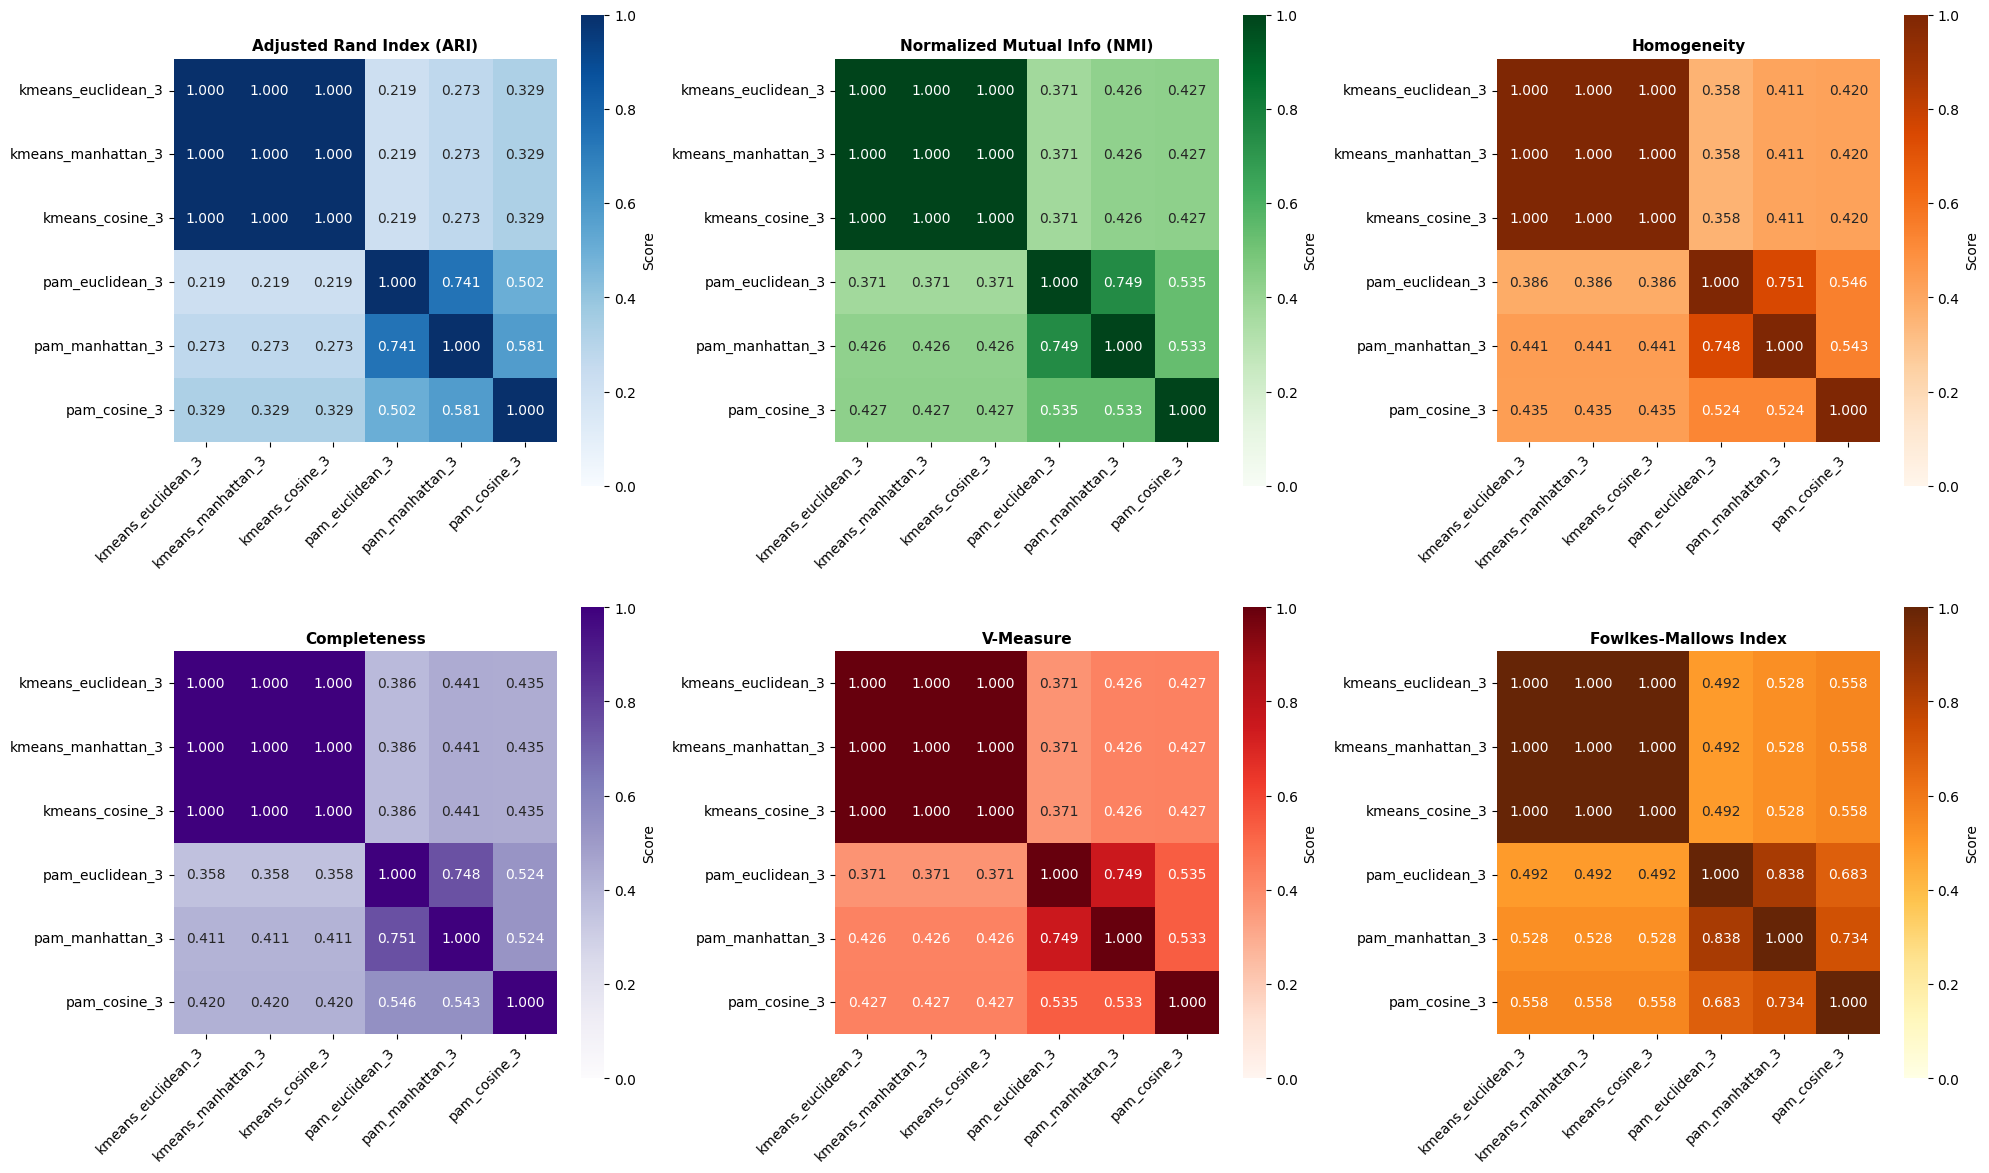


PART 2: WITHIN/BETWEEN CLUSTER STATISTICS

kmeans_euclidean_3:
--------------------------------------------------------------------------------
  Number of clusters: 3
  Total Within-Cluster SS: 536.31 (58.8%)
  Total Between-Cluster SS: 375.69 (41.2%)
  Average Within-Cluster SS: 178.77
  Average Between-Cluster SS: 125.23
  Average Within-Cluster Variance: 0.6225
  Between-Cluster Variance: 0.6100
  Average Within-Cluster Distance: 4.7168
  Average Between-Cluster Distance: 4.0695
  Separation Ratio (Between/Within): 0.8628
  Cluster Sizes: [np.int64(13), np.int64(16), np.int64(19)] (std: 2.45)

kmeans_manhattan_3:
--------------------------------------------------------------------------------
  Number of clusters: 3
  Total Within-Cluster SS: 536.31 (58.8%)
  Total Between-Cluster SS: 375.69 (41.2%)
  Average Within-Cluster SS: 178.77
  Average Between-Cluster SS: 125.23
  Average Within-Cluster Variance: 0.6225
  Between-Cluster Variance: 0.6100
  Average Within-Cluster Distance:

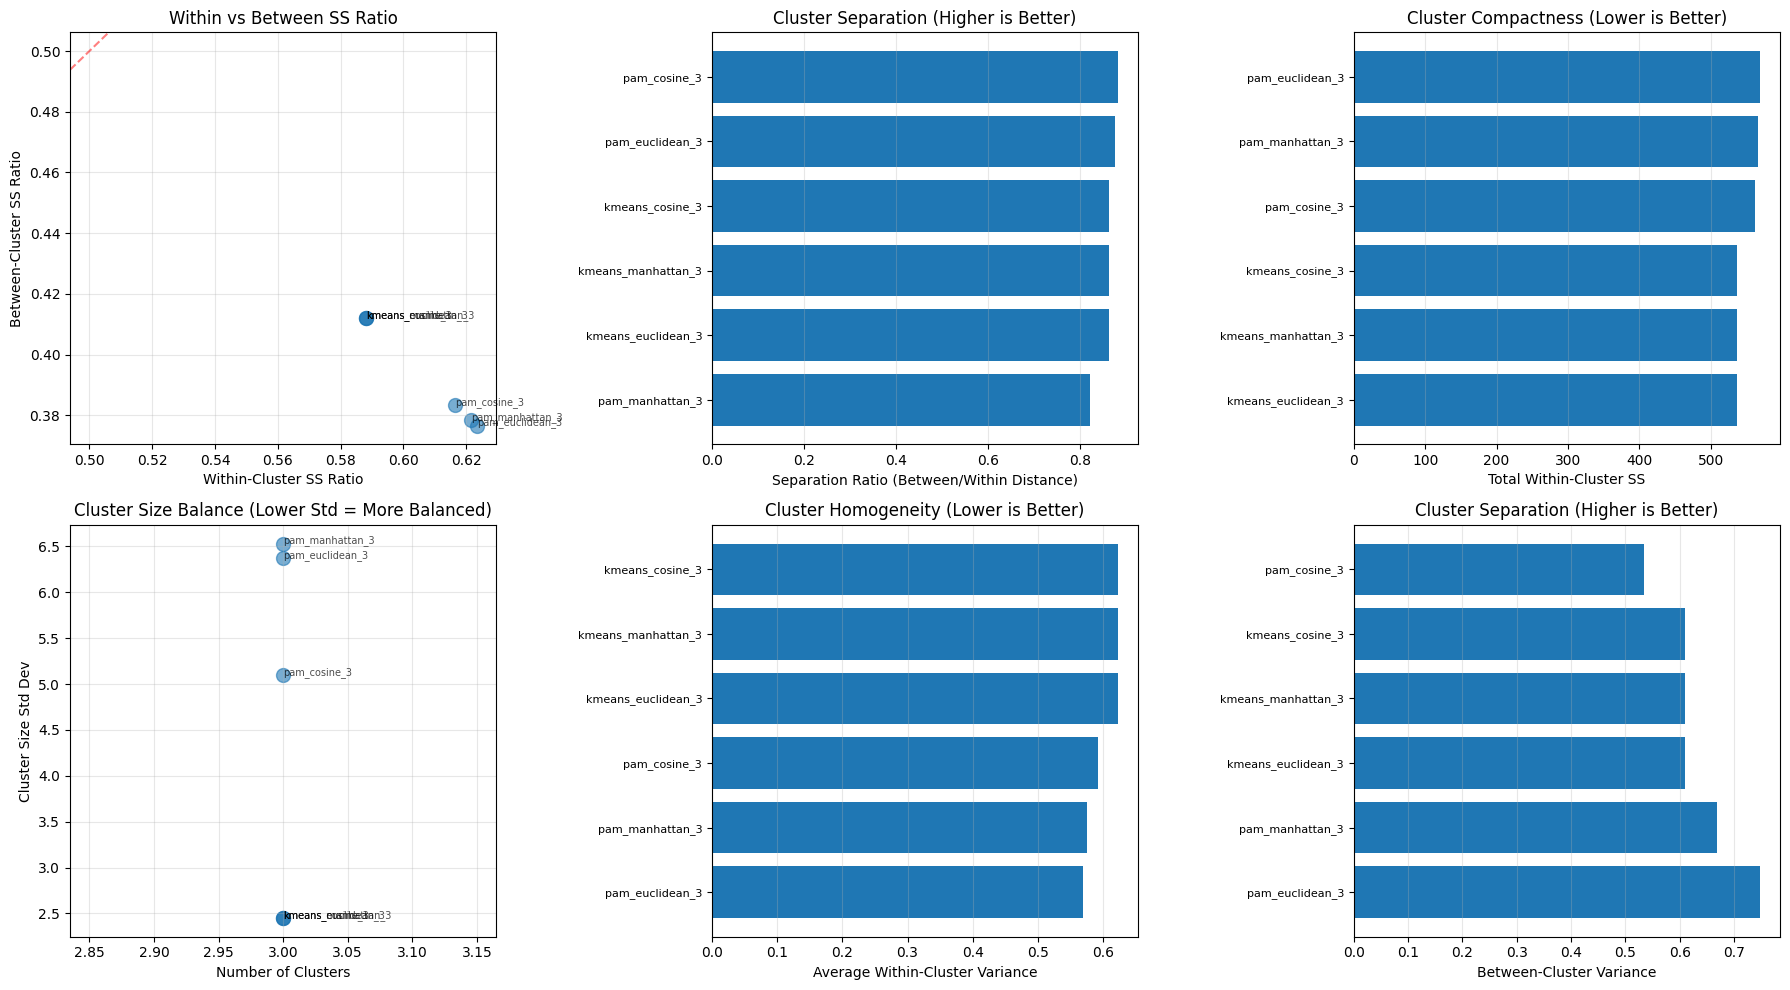


COMBINED SUMMARY

Top 5 Methods by Separation Ratio:
            method  separation_ratio  avg_ari_with_others  total_within_ss
      pam_cosine_3            0.8824               0.4143         562.3101
   pam_euclidean_3            0.8774               0.3798         568.5127
kmeans_euclidean_3            0.8628               0.5642         536.3076
kmeans_manhattan_3            0.8628               0.5642         536.3076
   kmeans_cosine_3            0.8628               0.5642         536.3076

Top 5 Methods by Average ARI (Agreement with Others):
            method  avg_ari_with_others  separation_ratio  total_within_ss
kmeans_euclidean_3               0.5642            0.8628         536.3076
kmeans_manhattan_3               0.5642            0.8628         536.3076
   kmeans_cosine_3               0.5642            0.8628         536.3076
   pam_manhattan_3               0.4280            0.8220         566.7521
      pam_cosine_3               0.4143            0.8824         

In [312]:
# Run complete analysis
results = complete_clustering_analysis(
    clusters=clusters,
    data=feature_scaled.values,  # Use original scaled data for statistics
    tickers=tickers
)

In [341]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. HIERARCHICAL CLUSTERING (Dendrogram)
# ============================================

def hierarchical_clustering_analysis(data, tickers, max_k=10, linkage_method='ward'):

    print("="*80)
    print("HIERARCHICAL CLUSTERING ANALYSIS")
    print("="*80)
    
    # Calculate linkage matrix
    if linkage_method == 'ward':
        # Ward requires Euclidean distance
        linkage_matrix = linkage(data, method='ward')
    else:
        # Other methods can use different distance metrics
        distances = pdist(data, metric='euclidean')
        linkage_matrix = linkage(distances, method=linkage_method)
    
    # Plot full dendrogram
    plt.figure(figsize=(20, 10))
    dendrogram(
        linkage_matrix,
        labels=tickers if len(tickers) <= 50 else None,  # Only show labels if not too many
        leaf_rotation=90,
        leaf_font_size=8,
        color_threshold=None  # Show all levels
    )
    plt.title(f'Hierarchical Clustering Dendrogram ({linkage_method} linkage)', fontsize=14, fontweight='bold')
    plt.xlabel('Stock Ticker', fontsize=12)
    plt.ylabel('Distance', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Test different k values and calculate metrics
    print(f"\nTesting k from 2 to {max_k}...")
    print(f"{'k':<5} {'Silhouette':<12} {'Davies-Bouldin':<15} {'Calinski-Harabasz':<18}")
    print("-" * 60)
    
    results = []
    for k in range(2, max_k + 1):
        labels = fcluster(linkage_matrix, k, criterion='maxclust')
        
        # Calculate metrics
        silhouette = silhouette_score(data, labels)
        db_score = davies_bouldin_score(data, labels)
        ch_score = calinski_harabasz_score(data, labels)
        
        # Cluster sizes
        cluster_sizes = np.bincount(labels)
        
        results.append({
            'k': k,
            'silhouette': silhouette,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score,
            'cluster_sizes': cluster_sizes
        })
        
        print(f"{k:<5} {silhouette:<12.4f} {db_score:<15.4f} {ch_score:<18.4f}")
        print(f"      Cluster sizes: {cluster_sizes}")
    
    results_df = pd.DataFrame(results)
    
    # Find optimal k
    optimal_k_sil = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
    optimal_k_db = int(results_df.loc[results_df['davies_bouldin'].idxmin(), 'k'])
    
    print(f"\nRecommended k (Silhouette): {optimal_k_sil}")
    print(f"Recommended k (Davies-Bouldin): {optimal_k_db}")
    
    # Visualize metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(results_df['k'], results_df['silhouette'], marker='o', linewidth=2, markersize=8)
    axes[0].axvline(x=optimal_k_sil, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_sil}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Hierarchical: Silhouette Score')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(results_df['k'], results_df['davies_bouldin'], marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].axvline(x=optimal_k_db, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k_db}')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Davies-Bouldin Score')
    axes[1].set_title('Hierarchical: Davies-Bouldin Score')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    axes[2].plot(results_df['k'], results_df['calinski_harabasz'], marker='o', linewidth=2, markersize=8, color='green')
    axes[2].set_xlabel('Number of Clusters (k)')
    axes[2].set_ylabel('Calinski-Harabasz Score')
    axes[2].set_title('Hierarchical: Calinski-Harabasz Score')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'linkage_matrix': linkage_matrix,
        'results_df': results_df,
        'optimal_k_silhouette': optimal_k_sil,
        'optimal_k_db': optimal_k_db
    }

# ============================================
# 2. GAP STATISTIC
# ============================================

def gap_statistic(data, k_max=10, n_refs=10, random_state=42):
    """
    Calculate Gap Statistic to find optimal number of clusters.
    
    Gap Statistic compares the total within intra-cluster variation for different
    values of k with their expected values under null reference distribution.
    
    Args:
        data: Feature matrix
        k_max: Maximum number of clusters to test
        n_refs: Number of reference datasets to generate
        random_state: Random seed
        
    Returns:
        Dictionary with gap values and optimal k
    """
    print("="*80)
    print("GAP STATISTIC ANALYSIS")
    print("="*80)
    print("This may take a while... Generating reference distributions...")
    
    np.random.seed(random_state)
    
    gaps = []
    sk_values = []
    k_range = range(1, k_max + 1)
    
    for k in k_range:
        # Fit clustering on actual data
        if k == 1:
            # For k=1, Wk is just total variance
            wk = np.sum((data - data.mean(axis=0))**2)
        else:
            kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
            kmeans.fit(data)
            wk = kmeans.inertia_
        
        # Generate reference datasets and calculate Wkb
        wk_refs = []
        for _ in range(n_refs):
            # Generate random reference data (uniform distribution within bounding box)
            random_data = np.random.uniform(
                low=data.min(axis=0),
                high=data.max(axis=0),
                size=data.shape
            )
            
            if k == 1:
                wk_ref = np.sum((random_data - random_data.mean(axis=0))**2)
            else:
                kmeans_ref = KMeans(n_clusters=k, random_state=None, n_init=10)
                kmeans_ref.fit(random_data)
                wk_ref = kmeans_ref.inertia_
            
            wk_refs.append(wk_ref)
        
        # Calculate Gap statistic
        gap = np.log(np.mean(wk_refs)) - np.log(wk)
        gaps.append(gap)
        
        # Calculate standard error
        sk = np.std(np.log(wk_refs)) * np.sqrt(1 + 1/n_refs)
        sk_values.append(sk)
        
        print(f"k={k:2d}: Gap={gap:.4f}, sk={sk:.4f}")
    
    gaps = np.array(gaps)
    sk_values = np.array(sk_values)
    
    # Find optimal k: smallest k such that Gap(k) >= Gap(k+1) - s(k+1)
    optimal_k = 1
    for k in range(len(gaps) - 1):
        if gaps[k] >= gaps[k + 1] - sk_values[k + 1]:
            optimal_k = k + 1
            break
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gap statistic plot
    axes[0].plot(k_range, gaps, marker='o', linewidth=2, markersize=8, label='Gap(k)')
    axes[0].errorbar(k_range, gaps, yerr=sk_values, fmt='none', alpha=0.5, label='±sk')
    axes[0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Gap Statistic')
    axes[0].set_title('Gap Statistic (Higher is Better)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Gap(k) - Gap(k+1) + s(k+1) plot
    gap_diff = []
    for k in range(len(gaps) - 1):
        diff = gaps[k] - (gaps[k + 1] - sk_values[k + 1])
        gap_diff.append(diff)
    
    axes[1].plot(list(k_range)[1:], gap_diff, marker='o', linewidth=2, markersize=8, color='green')
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, label=f'Optimal k={optimal_k}')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Gap(k) - [Gap(k+1) - s(k+1)]')
    axes[1].set_title('Gap Statistic Criterion')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal k (Gap Statistic): {optimal_k}")
    
    return {
        'gaps': gaps,
        'sk_values': sk_values,
        'optimal_k': optimal_k,
        'k_range': list(k_range)
    }

# ============================================
# 3. WSS (Within Sum of Squares) - Elbow Method
# ============================================

def wss_elbow_method(data, k_max=10, random_state=42, method='kmeans'):
    """
    Calculate Within Sum of Squares (WSS) / Inertia for Elbow Method.
    
    Args:
        data: Feature matrix
        k_max: Maximum number of clusters
        random_state: Random seed
        method: 'kmeans' or 'pam'
        
    Returns:
        Dictionary with WSS values and optimal k
    """
    print("="*80)
    print("WSS (ELBOW METHOD) ANALYSIS")
    print("="*80)
    
    k_range = range(1, k_max + 1)
    wss_values = []
    
    print(f"{'k':<5} {'WSS (Inertia)':<15} {'WSS Decrease':<15} {'% Decrease':<15}")
    print("-" * 60)
    
    for k in k_range:
        if method == 'kmeans':
            model = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        else:  # PAM
            model = KMedoids(n_clusters=k, metric='euclidean', random_state=random_state)
        
        model.fit(data)
        wss = model.inertia_
        wss_values.append(wss)
        
        # Calculate decrease from previous k
        if k > 1:
            wss_decrease = wss_values[-2] - wss
            pct_decrease = (wss_decrease / wss_values[-2]) * 100
            print(f"{k:<5} {wss:<15.2f} {wss_decrease:<15.2f} {pct_decrease:<15.2f}%")
        else:
            print(f"{k:<5} {wss:<15.2f} {'-':<15} {'-':<15}")
    
    wss_values = np.array(wss_values)
    
    # Calculate rate of change (second derivative approximation)
    # Elbow is where the rate of decrease slows down significantly
    wss_decrease_rate = np.diff(wss_values)
    wss_decrease_rate2 = np.diff(wss_decrease_rate)  # Second derivative
    
    # Find elbow: maximum of second derivative (where decrease rate changes most)
    if len(wss_decrease_rate2) > 0:
        optimal_k_elbow = np.argmax(wss_decrease_rate2) + 2  # +2 because we start from k=1
    else:
        optimal_k_elbow = 2
    
    # Alternative: Find k where decrease is less than threshold
    pct_decreases = []
    for i in range(1, len(wss_values)):
        pct_decrease = ((wss_values[i-1] - wss_values[i]) / wss_values[i-1]) * 100
        pct_decreases.append(pct_decrease)
    
    # Find where percentage decrease drops below threshold (e.g., 5%)
    threshold = 5.0
    optimal_k_threshold = 2
    for i, pct in enumerate(pct_decreases):
        if pct < threshold:
            optimal_k_threshold = i + 2
            break
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # WSS plot (Elbow curve)
    axes[0].plot(k_range, wss_values, marker='o', linewidth=2, markersize=8, color='blue')
    axes[0].axvline(x=optimal_k_elbow, color='r', linestyle='--', alpha=0.5, label=f'Elbow k={optimal_k_elbow}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('WSS (Within Sum of Squares)')
    axes[0].set_title(f'WSS Elbow Method ({method.upper()})')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # Rate of change
    axes[1].plot(list(k_range)[1:], wss_decrease_rate, marker='o', linewidth=2, markersize=8, color='orange')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('WSS Decrease Rate')
    axes[1].set_title('First Derivative (Rate of Change)')
    axes[1].grid(True, alpha=0.3)
    
    # Second derivative
    if len(wss_decrease_rate2) > 0:
        axes[2].plot(list(k_range)[2:], wss_decrease_rate2, marker='o', linewidth=2, markersize=8, color='green')
        axes[2].axvline(x=optimal_k_elbow, color='r', linestyle='--', alpha=0.5, label=f'Elbow k={optimal_k_elbow}')
        axes[2].set_xlabel('Number of Clusters (k)')
        axes[2].set_ylabel('Change in Decrease Rate')
        axes[2].set_title('Second Derivative (Elbow Detection)')
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal k (Elbow method): {optimal_k_elbow}")
    print(f"Optimal k (Threshold method, <{threshold}% decrease): {optimal_k_threshold}")
    
    return {
        'wss_values': wss_values,
        'k_range': list(k_range),
        'optimal_k_elbow': optimal_k_elbow,
        'optimal_k_threshold': optimal_k_threshold,
        'pct_decreases': pct_decreases
    }

# ============================================
# 4. PAIRWISE SUPPORT & PAIRWISE SUPPORT GLOBAL
# ============================================

def pairwise_support(data, labels, n_iterations=100, random_state=42):
    """
    Calculate Pairwise Support metrics for cluster stability.
    
    Pairwise Support: For each pair of points, how often are they in the same cluster
    across multiple runs? Measures cluster stability.
    
    Args:
        data: Feature matrix
        labels: Cluster labels from a single run
        n_iterations: Number of bootstrap iterations
        random_state: Random seed
        
    Returns:
        Dictionary with pairwise support metrics
    """
    print("="*80)
    print("PAIRWISE SUPPORT ANALYSIS")
    print("="*80)
    print(f"Running {n_iterations} bootstrap iterations...")
    
    np.random.seed(random_state)
    n_samples = len(data)
    n_clusters = len(np.unique(labels))
    
    # Create co-occurrence matrix
    cooccurrence_matrix = np.zeros((n_samples, n_samples))
    
    for iteration in range(n_iterations):
        # Bootstrap sample (sample with replacement)
        bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        bootstrap_data = data[bootstrap_indices]
        
        # Cluster bootstrap data
        kmeans = KMeans(n_clusters=n_clusters, random_state=None, n_init=10)
        bootstrap_labels = kmeans.fit_predict(bootstrap_data)
        
        # Map bootstrap labels back to original indices
        # (This is approximate - bootstrap indices may have duplicates)
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                orig_i = bootstrap_indices[i]
                orig_j = bootstrap_indices[j]
                
                # If both points are in bootstrap sample and in same cluster
                if bootstrap_labels[i] == bootstrap_labels[j]:
                    cooccurrence_matrix[orig_i, orig_j] += 1
                    cooccurrence_matrix[orig_j, orig_i] += 1
        
        if (iteration + 1) % 20 == 0:
            print(f"  Completed {iteration + 1}/{n_iterations} iterations...")
    
    # Normalize to get probabilities
    pairwise_support_matrix = cooccurrence_matrix / n_iterations
    
    # Calculate pairwise support for original clustering
    original_same_cluster = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            if labels[i] == labels[j]:
                original_same_cluster[i, j] = 1
    
    # Pairwise Support: Average probability that pairs in same cluster stay together
    same_cluster_pairs = []
    different_cluster_pairs = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            support = pairwise_support_matrix[i, j]
            if labels[i] == labels[j]:
                same_cluster_pairs.append(support)
            else:
                different_cluster_pairs.append(support)
    
    pairwise_support_same = np.mean(same_cluster_pairs) if same_cluster_pairs else 0
    pairwise_support_diff = np.mean(different_cluster_pairs) if different_cluster_pairs else 0
    
    # Pairwise Support Global: Overall stability
    # Higher when same-cluster pairs have high support and different-cluster pairs have low support
    pairwise_support_global = pairwise_support_same - pairwise_support_diff
    
    print(f"\nPairwise Support (same cluster pairs): {pairwise_support_same:.4f}")
    print(f"Pairwise Support (different cluster pairs): {pairwise_support_diff:.4f}")
    print(f"Pairwise Support Global: {pairwise_support_global:.4f} (higher is better)")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original clustering
    im1 = axes[0].imshow(original_same_cluster, cmap='RdYlGn', aspect='auto')
    axes[0].set_title('Original Clustering\n(1 = same cluster, 0 = different)')
    axes[0].set_xlabel('Stock Index')
    axes[0].set_ylabel('Stock Index')
    plt.colorbar(im1, ax=axes[0])
    
    # Pairwise support matrix
    im2 = axes[1].imshow(pairwise_support_matrix, cmap='viridis', aspect='auto')
    axes[1].set_title('Pairwise Support Matrix\n(Probability of being in same cluster)')
    axes[1].set_xlabel('Stock Index')
    axes[1].set_ylabel('Stock Index')
    plt.colorbar(im2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    return {
        'pairwise_support_same': pairwise_support_same,
        'pairwise_support_diff': pairwise_support_diff,
        'pairwise_support_global': pairwise_support_global,
        'pairwise_support_matrix': pairwise_support_matrix,
        'cooccurrence_matrix': cooccurrence_matrix
    }

def pairwise_support_multiple_k(data, k_range, n_iterations=50, random_state=42):
    """
    Calculate Pairwise Support Global for multiple k values to find optimal k.
    
    Args:
        data: Feature matrix
        k_range: Range of k values to test
        n_iterations: Number of bootstrap iterations (reduced for speed)
        random_state: Random seed
        
    Returns:
        Dictionary with pairwise support global for each k
    """
    print("="*80)
    print("PAIRWISE SUPPORT GLOBAL (Multiple k)")
    print("="*80)
    print("This will take a while...")
    
    results = []
    
    for k in k_range:
        print(f"\nTesting k={k}...")
        
        # Get base clustering
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        base_labels = kmeans.fit_predict(data)
        
        # Calculate pairwise support
        ps_result = pairwise_support(data, base_labels, n_iterations=n_iterations, 
                                     random_state=random_state + k)
        
        results.append({
            'k': k,
            'pairwise_support_global': ps_result['pairwise_support_global'],
            'pairwise_support_same': ps_result['pairwise_support_same'],
            'pairwise_support_diff': ps_result['pairwise_support_diff']
        })
        
        print(f"  Pairwise Support Global: {ps_result['pairwise_support_global']:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find optimal k (highest pairwise support global)
    optimal_k = int(results_df.loc[results_df['pairwise_support_global'].idxmax(), 'k'])
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(results_df['k'], results_df['pairwise_support_global'], 
                 marker='o', linewidth=2, markersize=8, color='blue')
    axes[0].axvline(x=optimal_k, color='r', linestyle='--', alpha=0.5, 
                    label=f'Optimal k={optimal_k}')
    axes[0].set_xlabel('Number of Clusters (k)')
    axes[0].set_ylabel('Pairwise Support Global')
    axes[0].set_title('Pairwise Support Global (Higher is Better)')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    axes[1].plot(results_df['k'], results_df['pairwise_support_same'], 
                 marker='o', linewidth=2, markersize=8, color='green', label='Same cluster')
    axes[1].plot(results_df['k'], results_df['pairwise_support_diff'], 
                 marker='s', linewidth=2, markersize=8, color='red', label='Different cluster')
    axes[1].set_xlabel('Number of Clusters (k)')
    axes[1].set_ylabel('Pairwise Support')
    axes[1].set_title('Pairwise Support Components')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOptimal k (Pairwise Support Global): {optimal_k}")
    
    return {
        'results_df': results_df,
        'optimal_k': optimal_k
    }

# ============================================
# COMPREHENSIVE COMPARISON
# ============================================

def comprehensive_optimal_k_analysis(data, tickers, k_max=10, output_dir='ml/data/clustering'):
    """
    Run all methods and compare results.
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE OPTIMAL K ANALYSIS")
    print("="*80)
    
    results_summary = []
    
    # 1. Hierarchical
    print("\n[1/5] Running Hierarchical Clustering...")
    hier_results = hierarchical_clustering_analysis(data, tickers, max_k=k_max)
    results_summary.append({
        'method': 'Hierarchical (Silhouette)',
        'optimal_k': hier_results['optimal_k_silhouette']
    })
    results_summary.append({
        'method': 'Hierarchical (DB)',
        'optimal_k': hier_results['optimal_k_db']
    })
    
    # 2. Gap Statistic
    print("\n[2/5] Running Gap Statistic...")
    gap_results = gap_statistic(data, k_max=k_max, n_refs=10)
    results_summary.append({
        'method': 'Gap Statistic',
        'optimal_k': gap_results['optimal_k']
    })
    
    # 3. WSS Elbow (K-Means)
    print("\n[3/5] Running WSS Elbow Method (K-Means)...")
    wss_kmeans = wss_elbow_method(data, k_max=k_max, method='kmeans')
    results_summary.append({
        'method': 'WSS Elbow (K-Means)',
        'optimal_k': wss_kmeans['optimal_k_elbow']
    })
    
    # 4. WSS Elbow (PAM)
    print("\n[4/5] Running WSS Elbow Method (PAM)...")
    wss_pam = wss_elbow_method(data, k_max=k_max, method='pam')
    results_summary.append({
        'method': 'WSS Elbow (PAM)',
        'optimal_k': wss_pam['optimal_k_elbow']
    })
    
    # 5. Pairwise Support (single k test - can be slow, so optional)
    print("\n[5/5] Running Pairwise Support Global (Multiple k)...")
    print("Note: This is computationally expensive. Consider reducing n_iterations.")
    ps_results = pairwise_support_multiple_k(data, range(2, min(k_max+1, 8)), 
                                             n_iterations=30)  # Reduced for speed
    results_summary.append({
        'method': 'Pairwise Support Global',
        'optimal_k': ps_results['optimal_k']
    })
    
    # Summary
    summary_df = pd.DataFrame(results_summary)
    
    print("\n" + "="*80)
    print("SUMMARY: OPTIMAL K BY METHOD")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    # Most common optimal k
    mode_k = summary_df['optimal_k'].mode()
    if len(mode_k) > 0:
        print(f"\nMost common optimal k: {mode_k[0]}")
        print(f"Average optimal k: {summary_df['optimal_k'].mean():.1f}")
        print(f"Median optimal k: {summary_df['optimal_k'].median():.1f}")
    
    return {
        'summary': summary_df,
        'hierarchical': hier_results,
        'gap': gap_results,
        'wss_kmeans': wss_kmeans,
        'wss_pam': wss_pam,
        'pairwise_support': ps_results
    }

# ============================================
# USAGE EXAMPLE
# ============================================

# Run comprehensive analysis
# comprehensive_results = comprehensive_optimal_k_analysis(
#     data=global_scaled[numeric_cols].values,  # or global_pca
#     tickers=tickers,
#     k_max=10,
#     output_dir='ml/data/clustering'
# )

# Or run individual methods:
# hier_results = hierarchical_clustering_analysis(global_pca, tickers, max_k=10)
# gap_results = gap_statistic(global_pca, k_max=10)
# wss_results = wss_elbow_method(global_pca, k_max=10, method='pam')
# ps_results = pairwise_support_multiple_k(global_pca, range(2, 8), n_iterations=30)

In [342]:
comprehensive_results = comprehensive_optimal_k_analysis(
    data=feature_pca,  # or global_pca
    tickers=tickers,
    k_max=10
)


COMPREHENSIVE OPTIMAL K ANALYSIS

[1/5] Running Hierarchical Clustering...
HIERARCHICAL CLUSTERING ANALYSIS


KeyError: -43

<Figure size 2000x1000 with 0 Axes>

In [347]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    confusion_matrix
)

# ============================================
# COMPARE CLUSTERS WITH RISK PROFILES
# ============================================

def compare_clusters_with_labels(cluster_labels, tickers, label_mapping, label_name='Label'):
    # Create dataframe with cluster and labels
    comparison_df = pd.DataFrame({
        'ticker': tickers,
        'cluster': cluster_labels
    })
    
    # Add label information
    comparison_df[label_name] = comparison_df['ticker'].map(SYMBOL_TO_RISK_CATEGORY)
    
    
    print("="*80)
    print(f"CLUSTER vs {label_name.upper()} COMPARISON")
    print("="*80)
    print(f"\nTotal stocks: {len(comparison_df)}")
    print(f"Number of clusters: {len(comparison_df['cluster'].unique())}")
    print(f"Number of {label_name}s: {len(comparison_df[label_name].unique())}")
    
    # Calculate agreement metrics
    cluster_labels_numeric = comparison_df['cluster'].values
    true_labels = comparison_df[label_name].values
    
    # Convert labels to numeric for metrics
    label_to_num = {label: i for i, label in enumerate(sorted(comparison_df[label_name].unique()))}
    true_labels_numeric = np.array([label_to_num[label] for label in true_labels])
    
    # Calculate metrics
    ari = adjusted_rand_score(true_labels_numeric, cluster_labels_numeric)
    nmi = normalized_mutual_info_score(true_labels_numeric, cluster_labels_numeric)
    homogeneity = homogeneity_score(true_labels_numeric, cluster_labels_numeric)
    completeness = completeness_score(true_labels_numeric, cluster_labels_numeric)
    v_measure = v_measure_score(true_labels_numeric, cluster_labels_numeric)
    
    print("\n" + "-"*80)
    print("AGREEMENT METRICS")
    print("-"*80)
    print(f"Adjusted Rand Index (ARI):        {ari:.4f}  (1.0 = perfect match, 0.0 = random)")
    print(f"Normalized Mutual Info (NMI):     {nmi:.4f}  (1.0 = perfect match, 0.0 = independent)")
    print(f"Homogeneity:                      {homogeneity:.4f}  (1.0 = all clusters contain only one {label_name})")
    print(f"Completeness:                     {completeness:.4f}  (1.0 = all stocks of same {label_name} in same cluster)")
    print(f"V-Measure:                        {v_measure:.4f}  (harmonic mean of homogeneity & completeness)")
    
    # Interpretation
    print("\n" + "-"*80)
    print("INTERPRETATION")
    print("-"*80)
    if ari > 0.5:
        print(f"✓ Strong agreement: Clusters align well with {label_name}s")
    elif ari > 0.3:
        print(f"~ Moderate agreement: Some alignment with {label_name}s")
    else:
        print(f"✗ Weak agreement: Clusters don't align well with {label_name}s")
        print(f"  → This might be GOOD! Your clusters may be finding behavioral patterns")
        print(f"    that transcend traditional {label_name} boundaries")
    
    # Create confusion matrix (label vs cluster)
    print("\n" + "-"*80)
    print(f"{label_name.upper()} DISTRIBUTION BY CLUSTER")
    print("-"*80)
    
    # Cross-tabulation
    crosstab = pd.crosstab(comparison_df['cluster'], comparison_df[label_name], margins=True)
    print("\nCross-tabulation (Cluster × " + label_name + "):")
    print(crosstab)
    
    # Percentage distribution
    crosstab_pct = pd.crosstab(comparison_df['cluster'], comparison_df[label_name], normalize='index') * 100
    print("\nPercentage distribution (rows sum to 100%):")
    print(crosstab_pct.round(1))
    
    # Visualizations
    fig = plt.figure(figsize=(16, 12))
    
    # 1. Confusion Matrix Heatmap (Count)
    ax1 = plt.subplot(2, 2, 1)
    crosstab_no_margin = pd.crosstab(comparison_df['cluster'], comparison_df[label_name])
    sns.heatmap(
        crosstab_no_margin,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar_kws={'label': 'Number of Stocks'},
        ax=ax1
    )
    ax1.set_title(f'{label_name} Distribution by Cluster\n(Count)', fontsize=12, fontweight='bold')
    ax1.set_xlabel(label_name, fontsize=10)
    ax1.set_ylabel('Cluster', fontsize=10)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # 2. Percentage Heatmap
    ax2 = plt.subplot(2, 2, 2)
    sns.heatmap(
        crosstab_pct,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        cbar_kws={'label': 'Percentage (%)'},
        ax=ax2
    )
    ax2.set_title(f'{label_name} Distribution by Cluster\n(Percentage)', fontsize=12, fontweight='bold')
    ax2.set_xlabel(label_name, fontsize=10)
    ax2.set_ylabel('Cluster', fontsize=10)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    
    # 3. Cluster composition (stacked bar chart)
    ax3 = plt.subplot(2, 2, 3)
    crosstab_no_margin.plot(kind='bar', stacked=True, ax=ax3, colormap='tab10')
    ax3.set_title(f'Cluster Composition by {label_name}', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster', fontsize=10)
    ax3.set_ylabel('Number of Stocks', fontsize=10)
    ax3.legend(title=label_name, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # 4. Dominant label per cluster
    ax4 = plt.subplot(2, 2, 4)
    dominant_labels = []
    for cluster_id in sorted(comparison_df['cluster'].unique()):
        cluster_data = comparison_df[comparison_df['cluster'] == cluster_id]
        label_counts = cluster_data[label_name].value_counts()
        dominant_label = label_counts.index[0]
        dominant_pct = (label_counts.iloc[0] / len(cluster_data)) * 100
        dominant_labels.append({
            'cluster': cluster_id,
            f'dominant_{label_name.lower()}': dominant_label,
            'dominant_pct': dominant_pct,
            'n_stocks': len(cluster_data)
        })
    
    dominant_df = pd.DataFrame(dominant_labels)
    bars = ax4.bar(dominant_df['cluster'], dominant_df['dominant_pct'],
                   color=plt.cm.tab10(np.linspace(0, 1, len(dominant_df))))
    ax4.set_title(f'Dominant {label_name} per Cluster', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Cluster', fontsize=10)
    ax4.set_ylabel(f'Percentage of Dominant {label_name} (%)', fontsize=10)
    ax4.set_ylim(0, 100)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for idx, row in dominant_df.iterrows():
        ax4.text(row['cluster'], row['dominant_pct'] + 2,
                f"{row[f'dominant_{label_name.lower()}']}\n({row['dominant_pct']:.1f}%)",
                ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Detailed cluster analysis
    print("\n" + "="*80)
    print("DETAILED CLUSTER ANALYSIS")
    print("="*80)
    
    for cluster_id in sorted(comparison_df['cluster'].unique()):
        cluster_data = comparison_df[comparison_df['cluster'] == cluster_id]
        label_counts = cluster_data[label_name].value_counts()
        
        print(f"\nCluster {cluster_id} ({len(cluster_data)} stocks):")
        print(f"  Tickers: {', '.join(cluster_data['ticker'].tolist())}")
        print(f"  {label_name} distribution:")
        for label, count in label_counts.items():
            pct = (count / len(cluster_data)) * 100
            print(f"    {str(label):25s}: {count:2d} stocks ({pct:5.1f}%)")
        
        # Purity: percentage of dominant label
        purity = (label_counts.iloc[0] / len(cluster_data)) * 100
        print(f"  Cluster Purity: {purity:.1f}%")
    
    # Label analysis
    print("\n" + "="*80)
    print(f"{label_name.upper()} ANALYSIS")
    print("="*80)
    
    for label in sorted(comparison_df[label_name].unique()):
        label_data = comparison_df[comparison_df[label_name] == label]
        cluster_counts = label_data['cluster'].value_counts()
        
        print(f"\n{label} ({len(label_data)} stocks):")
        print(f"  Tickers: {', '.join(label_data['ticker'].tolist())}")
        print(f"  Cluster distribution:")
        for cluster_id, count in cluster_counts.items():
            pct = (count / len(label_data)) * 100
            print(f"    Cluster {cluster_id}: {count:2d} stocks ({pct:5.1f}%)")
        
        # Cohesion: percentage in most common cluster
        cohesion = (cluster_counts.iloc[0] / len(label_data)) * 100
        print(f"  {label_name} Cohesion: {cohesion:.1f}%")
    
    
    metrics_df = pd.DataFrame({
        'metric': ['ARI', 'NMI', 'Homogeneity', 'Completeness', 'V-Measure'],
        'value': [ari, nmi, homogeneity, completeness, v_measure]
    })
    
    return {
        'comparison_df': comparison_df,
        'metrics': {
            'ari': ari,
            'nmi': nmi,
            'homogeneity': homogeneity,
            'completeness': completeness,
            'v_measure': v_measure
        },
        'crosstab': crosstab_no_margin,
        'crosstab_pct': crosstab_pct,
        'dominant_labels': dominant_df
    }

# ============================================
# SPECIFIC FUNCTION FOR RISK PROFILES
# ============================================

def compare_clusters_with_risk_profiles(cluster_labels, tickers, risk_mapping, output_dir='ml/data/clustering'):
    """
    Compare cluster assignments with risk profile labels.
    
    Args:
        cluster_labels: Array of cluster labels
        tickers: Array of ticker symbols
        risk_mapping: Dictionary mapping ticker -> risk profile (e.g., SYMBOL_TO_RISK_CATEGORY)
        output_dir: Directory to save outputs
        
    Returns:
        Dictionary with comparison results
    """
    return compare_clusters_with_labels(
        cluster_labels=cluster_labels,
        tickers=tickers,
        label_mapping=risk_mapping,
        label_name='Risk_Profile'
    )

# ============================================
# COMPARE ALL CLUSTERING METHODS WITH RISK PROFILES
# ============================================

def compare_all_clusters_with_risk_profiles(clusters, tickers, risk_mapping, output_dir='ml/data/clustering'):
    """
    Compare all clustering results from cluster_loop() with risk profiles.
    
    Args:
        clusters: Dictionary from cluster_loop() with clustering results
        tickers: Array of ticker symbols
        risk_mapping: Dictionary mapping ticker -> risk profile
        output_dir: Output directory
        
    Returns:
        Dictionary with comparison results for each method
    """
    print("="*80)
    print("COMPARING ALL CLUSTERING METHODS WITH RISK PROFILES")
    print("="*80)
    
    all_results = {}
    summary_results = []
    
    for method_name, cluster_result in clusters.items():
        print(f"\n{'='*80}")
        print(f"METHOD: {method_name}")
        print('='*80)
        
        labels = cluster_result['labels']
        
        result = compare_clusters_with_risk_profiles(
            cluster_labels=labels,
            tickers=tickers,
            risk_mapping=risk_mapping,
            output_dir=output_dir
        )
        
        all_results[method_name] = result
        
        # Add to summary
        summary_results.append({
            'method': method_name,
            'ari': result['metrics']['ari'],
            'nmi': result['metrics']['nmi'],
            'homogeneity': result['metrics']['homogeneity'],
            'completeness': result['metrics']['completeness'],
            'v_measure': result['metrics']['v_measure']
        })
    
    # Summary comparison
    summary_df = pd.DataFrame(summary_results)
    summary_df = summary_df.sort_values('ari', ascending=False)
    
    print("\n" + "="*80)
    print("SUMMARY: RISK PROFILE ALIGNMENT BY METHOD")
    print("="*80)
    print(summary_df.to_string(index=False))
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    summary_df_sorted = summary_df.sort_values('ari', ascending=True)
    
    axes[0].barh(range(len(summary_df_sorted)), summary_df_sorted['ari'])
    axes[0].set_yticks(range(len(summary_df_sorted)))
    axes[0].set_yticklabels(summary_df_sorted['method'], fontsize=9)
    axes[0].set_xlabel('Adjusted Rand Index (Higher is Better)')
    axes[0].set_title('Risk Profile Alignment by Method')
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].axvline(x=0.5, color='r', linestyle='--', alpha=0.5, label='Strong Agreement Threshold')
    axes[0].legend()
    
    axes[1].barh(range(len(summary_df_sorted)), summary_df_sorted['v_measure'])
    axes[1].set_yticks(range(len(summary_df_sorted)))
    axes[1].set_yticklabels(summary_df_sorted['method'], fontsize=9)
    axes[1].set_xlabel('V-Measure (Higher is Better)')
    axes[1].set_title('Risk Profile Alignment by Method')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Save summary
    summary_df.to_parquet(f'{output_dir}/risk_profile_alignment_summary.parquet')
    
    return {
        'all_results': all_results,
        'summary': summary_df
    }

# ============================================
# USAGE EXAMPLES
# ============================================

# Example 1: Compare single clustering result with risk profiles
# Assuming you have SYMBOL_TO_RISK_CATEGORY defined:
# SYMBOL_TO_RISK_CATEGORY = {
#     "AAPL": "Low Risk",
#     "TSLA": "High Risk",
#     # ... etc
# }

# result = compare_clusters_with_risk_profiles(
#     cluster_labels=clusters['pam_euclidean_3']['labels'],
#     tickers=tickers,
#     risk_mapping=SYMBOL_TO_RISK_CATEGORY,
#     output_dir='ml/data/clustering'
# )

# Example 2: Compare all clustering methods
# all_risk_comparisons = compare_all_clusters_with_risk_profiles(
#     clusters=clusters,
#     tickers=tickers,
#     risk_mapping=SYMBOL_TO_RISK_CATEGORY,
#     output_dir='ml/data/clustering'
# )

# Example 3: Generic function for any label mapping
# result = compare_clusters_with_labels(
#     cluster_labels=clusters['pam_euclidean_3']['labels'],
#     tickers=tickers,
#     label_mapping=SYMBOL_TO_RISK_CATEGORY,  # or SYMBOL_TO_SECTOR
#     label_name='Risk_Profile',  # or 'Sector'
#     output_dir='ml/data/clustering'
# )

CLUSTER vs RISK_PROFILE COMPARISON

Total stocks: 48
Number of clusters: 3
Number of Risk_Profiles: 3

--------------------------------------------------------------------------------
AGREEMENT METRICS
--------------------------------------------------------------------------------
Adjusted Rand Index (ARI):        0.1029  (1.0 = perfect match, 0.0 = random)
Normalized Mutual Info (NMI):     0.1940  (1.0 = perfect match, 0.0 = independent)
Homogeneity:                      0.1898  (1.0 = all clusters contain only one Risk_Profile)
Completeness:                     0.1984  (1.0 = all stocks of same Risk_Profile in same cluster)
V-Measure:                        0.1940  (harmonic mean of homogeneity & completeness)

--------------------------------------------------------------------------------
INTERPRETATION
--------------------------------------------------------------------------------
✗ Weak agreement: Clusters don't align well with Risk_Profiles
  → This might be GOOD! Your cluster

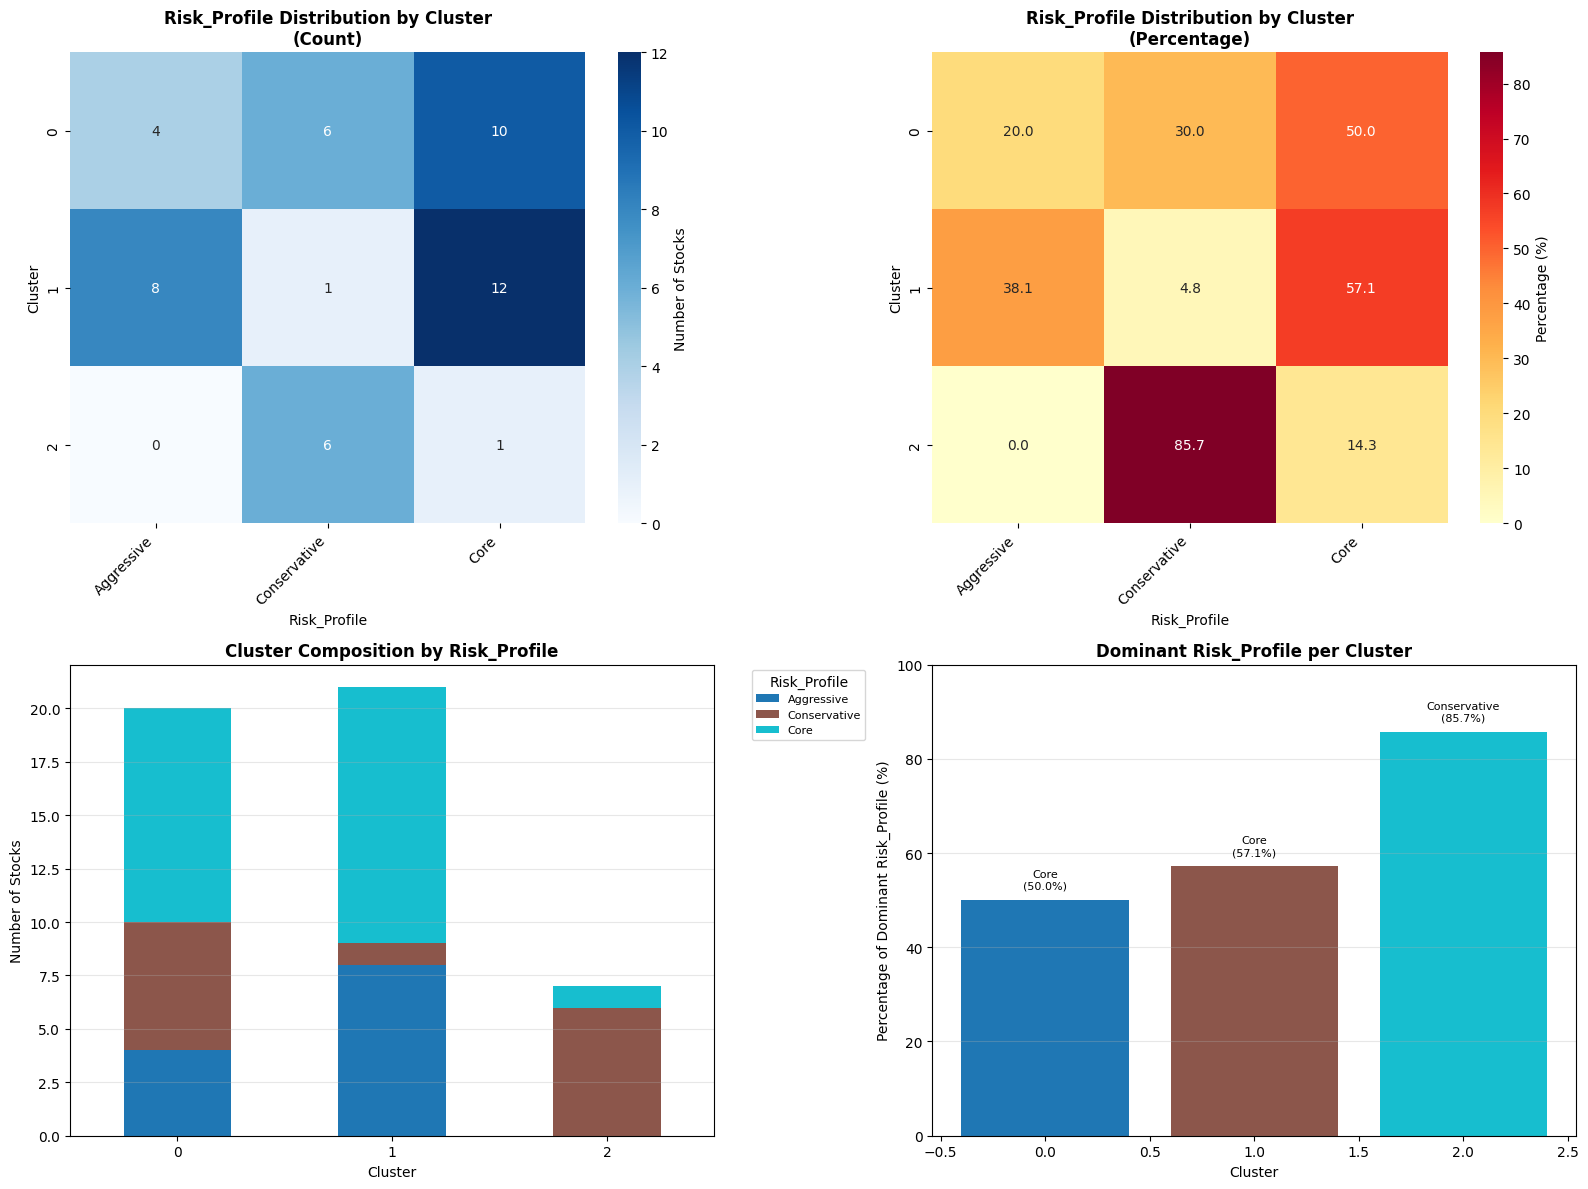


DETAILED CLUSTER ANALYSIS

Cluster 0 (20 stocks):
  Tickers: AAPL, ABBV, BA, BAC, COST, CVX, DIS, F, HD, JNJ, KO, LLY, MA, MSFT, NEE, NFLX, T, TM, V, XOM
  Risk_Profile distribution:
    Core                     : 10 stocks ( 50.0%)
    Conservative             :  6 stocks ( 30.0%)
    Aggressive               :  4 stocks ( 20.0%)
  Cluster Purity: 50.0%

Cluster 1 (21 stocks):
  Tickers: AMZN, AXP, BABA, CAT, CSCO, GM, GOOGL, GS, HSBC, IBM, INTC, JPM, META, MS, NVDA, ORCL, SPY, TSLA, TSM, WFC, WMT
  Risk_Profile distribution:
    Core                     : 12 stocks ( 57.1%)
    Aggressive               :  8 stocks ( 38.1%)
    Conservative             :  1 stocks (  4.8%)
  Cluster Purity: 57.1%

Cluster 2 (7 stocks):
  Tickers: CMCSA, COP, MRK, PEP, PFE, PG, TGT
  Risk_Profile distribution:
    Conservative             :  6 stocks ( 85.7%)
    Core                     :  1 stocks ( 14.3%)
  Cluster Purity: 85.7%

RISK_PROFILE ANALYSIS

Aggressive (12 stocks):
  Tickers: AMZN, BA, B

In [348]:
result = compare_clusters_with_risk_profiles(
    cluster_labels=clusters['pam_euclidean_3']['labels'],
    tickers=tickers,
    risk_mapping=SYMBOL_TO_RISK_CATEGORY,  # Your risk mapping
)

In [351]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# ============================================
# 4. PAIRWISE SUPPORT & PAIRWISE SUPPORT GLOBAL (FIXED)
# ============================================

def pairwise_support(data, labels, n_iterations=100, random_state=42):
    """
    Calculate Pairwise Support metrics for cluster stability.
    Robust against DataFrame indexing issues by converting to numpy first.
    """
    # --- FIX: Convert to NumPy to prevent IndexErrors ---
    if isinstance(data, pd.DataFrame):
        data_np = data.values
    else:
        data_np = data
        
    n_samples = len(data_np)
    n_clusters = len(np.unique(labels))
    
    np.random.seed(random_state)
    
    # Create co-occurrence matrix
    cooccurrence_matrix = np.zeros((n_samples, n_samples))
    
    print(f"Running {n_iterations} bootstrap iterations...")
    
    for iteration in range(n_iterations):
        # Bootstrap sample (sample with replacement)
        # We generate INDICES, not data directly
        bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        bootstrap_data = data_np[bootstrap_indices]
        
        # Cluster bootstrap data
        # Note: We use K-Means for speed in bootstrapping, even if main model is PAM
        # This is standard practice for stability analysis
        kmeans = KMeans(n_clusters=n_clusters, random_state=None, n_init=10)
        bootstrap_labels = kmeans.fit_predict(bootstrap_data)
        
        # Map bootstrap labels back to original indices
        # We iterate through the bootstrapped sample to see who ended up together
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                # Get the original indices of the two points we are comparing
                orig_i = bootstrap_indices[i]
                orig_j = bootstrap_indices[j]
                
                # If these two points ended up in the same cluster in this specific run
                if bootstrap_labels[i] == bootstrap_labels[j]:
                    cooccurrence_matrix[orig_i, orig_j] += 1
                    cooccurrence_matrix[orig_j, orig_i] += 1
        
        if (iteration + 1) % 20 == 0:
            print(f"  Completed {iteration + 1}/{n_iterations} iterations...")
    
    # Normalize to get probabilities (0.0 to 1.0)
    pairwise_support_matrix = cooccurrence_matrix / n_iterations
    
    # Calculate metrics based on the ORIGINAL labels
    same_cluster_pairs = []
    different_cluster_pairs = []
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            support = pairwise_support_matrix[i, j]
            if labels[i] == labels[j]:
                same_cluster_pairs.append(support)
            else:
                different_cluster_pairs.append(support)
    
    avg_support_same = np.mean(same_cluster_pairs) if same_cluster_pairs else 0
    avg_support_diff = np.mean(different_cluster_pairs) if different_cluster_pairs else 0
    
    # Global Score: Ideally, Same=1.0 and Diff=0.0, so Global=1.0
    pairwise_support_global = avg_support_same - avg_support_diff
    
    return {
        'pairwise_support_same': avg_support_same,
        'pairwise_support_diff': avg_support_diff,
        'pairwise_support_global': pairwise_support_global,
        'matrix': pairwise_support_matrix
    }

def pairwise_support_multiple_k(data, k_range, n_iterations=50, random_state=42):
    """
    Wrapper to run pairwise support for multiple k values.
    """
    print("="*80)
    print("PAIRWISE SUPPORT GLOBAL (Multiple k)")
    print("="*80)
    
    # --- FIX: Convert to NumPy once here ---
    if isinstance(data, pd.DataFrame):
        data_np = data.values
    else:
        data_np = data
        
    results = []
    
    for k in k_range:
        print(f"\nTesting k={k}...")
        
        # 1. Get Base Clustering (The reference)
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        base_labels = kmeans.fit_predict(data_np)
        
        # 2. Run Stability Analysis
        ps_result = pairwise_support(data_np, base_labels, n_iterations=n_iterations, 
                                     random_state=random_state + k)
        
        results.append({
            'k': k,
            'pairwise_support_global': ps_result['pairwise_support_global'],
            'pairwise_support_same': ps_result['pairwise_support_same'],
            'pairwise_support_diff': ps_result['pairwise_support_diff']
        })
        
        print(f"  -> Global Stability Score: {ps_result['pairwise_support_global']:.4f}")
    
    results_df = pd.DataFrame(results)
    
    # Find optimal k
    optimal_k = int(results_df.loc[results_df['pairwise_support_global'].idxmax(), 'k'])
    print(f"\n🏆 Optimal k (Pairwise Support): {optimal_k}")
    
    return {
        'results_df': results_df,
        'optimal_k': optimal_k
    }

In [352]:
comprehensive_results = comprehensive_optimal_k_analysis(
    data=feature_pca, 
    tickers=tickers, # A list of ticker strings
    k_max=10
)


COMPREHENSIVE OPTIMAL K ANALYSIS

[1/5] Running Hierarchical Clustering...
HIERARCHICAL CLUSTERING ANALYSIS


KeyError: -43

<Figure size 2000x1000 with 0 Axes>